# 쿨링 샴푸 통합 마케팅 분석

상품 분석 데이터와 리뷰 텍스트 분석 결과를 연결하여 상품이 전달한 메시지와 소비자가 실제 경험한 내용을 비교합니다.
브랜드, 가격대, 옵션 구성, 소비자 유형을 함께 분석해 상품 전략과 마케팅 인사이트로 이어갑니다.

## 현재 노트북의 범위

이 노트북은 앞선 상품 분석, 리뷰 정량 분석, 리뷰 텍스트 분석 결과를 하나의 데이터로 연결하는 통합 분석 파트입니다.

- 상품 분석 데이터와 리뷰 텍스트 분석 결과를 연결합니다.
- 상품명, 브랜드, 가격대, 옵션혜택이 실제 리뷰 반응과 어떻게 이어지는지 확인합니다.
- 04번에서 만든 페르소나, 긍정/부정 신호, 핵심 경험 주제 컬럼을 활용합니다.
- 최종적으로 상품 전략과 마케팅 인사이트를 도출합니다.

브랜드 설계, 대표 상품 컨셉, 경쟁사 분석, 콘텐츠 제작 방향은 포트폴리오 웹사이트에서 정리합니다.

## 데이터 설명

이번 분석에는 상품 단위 데이터와 리뷰 단위 텍스트 분석 데이터를 함께 사용합니다.  
05번에서는 두 데이터를 연결한 뒤, 분석 가능한 최종 데이터셋을 별도로 저장합니다.

### 상품 분석 데이터

- 파일: data/oliveyoung_cooling_shampoo_product_cleaned.csv  
- 역할: 02번에서 정리한 상품 단위 데이터입니다. `상품이 시장에서 어떤 가격과 메시지로 노출되어 있는지` 확인합니다.  
- 주요 컬럼: 브랜드, 상품명, 리뷰순위, 페이지, 가격, 가격대, 상품URL

### 리뷰 텍스트 분석 데이터

- 파일: data/oliveyoung_cooling_shampoo_reviews_text_features.csv  
- 역할: 04번에서 만든 리뷰 단위 텍스트 분석 데이터입니다. `소비자 유형, 긍정/부정 신호, 주요 경험 주제`를 확인합니다.  
- 주요 컬럼: 옵션혜택, 리뷰내용, 리뷰평점, 도움돼요점수, 페르소나, 대표키워드, 메시지 방향, 긍정/부정 신호, 쿨링·향·두피·자극·가격/구성 관련 신호

### 최종 데이터셋

- 파일: data/oliveyoung_cooling_shampoo_integrated_data.csv  
- 역할: 상품 분석 데이터와 리뷰 텍스트 분석 데이터를 브랜드, 상품명 기준으로 연결한 데이터입니다. `상품 메시지와 실제 소비자 경험을 함께 비교`하기 위해 사용합니다.  
- 주요 컬럼: 브랜드, 상품명, 가격, 가격대, 옵션혜택, 페르소나, 상품군, 긍정, 부정, 유분세정언급여부

## 1. 라이브러리 불러오기

통합 데이터 생성과 품질 확인에 필요한 라이브러리를 불러옵니다.

In [1]:
# 기본 데이터 처리 라이브러리
import re
import sys
import warnings
import subprocess
import numpy as np
import pandas as pd

In [2]:
# 시각화 라이브러리
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import networkx as nx
import plotly.graph_objects as go

In [3]:
# 트리맵 시각화 라이브러리
try:
    import squarify
except ModuleNotFoundError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "squarify"])
    import squarify

In [4]:
# 상품군 클러스터링 라이브러리
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [5]:
# 경고 메시지와 데이터프레임 출력 옵션 설정
warnings.filterwarnings("ignore", message="This pattern is interpreted as a regular expression.*")
warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.float_format", "{:,.2f}".format)

In [6]:
# 한글 폰트와 시각화 테마 설정
plt.rcParams["font.family"] = "AppleGothic"
plt.rcParams["axes.unicode_minus"] = False
sns.set_theme(style="whitegrid", font="AppleGothic", rc={"axes.unicode_minus": False})

In [7]:
# 반복해서 사용하는 퍼센트 축과 히트맵 함수
def set_percent_axis(ax, axis="y"):
    formatter = mtick.PercentFormatter(1.0)
    if axis == "x":
        ax.xaxis.set_major_formatter(formatter)
    elif axis == "y":
        ax.yaxis.set_major_formatter(formatter)
    else:
        ax.xaxis.set_major_formatter(formatter)
        ax.yaxis.set_major_formatter(formatter)

def draw_percent_heatmap(data, title, cmap="YlGnBu", ax=None):
    annot = data.map(lambda x: f"{x:.0%}")
    sns.heatmap(data, annot=annot, fmt="", cmap=cmap, ax=ax, cbar_kws={"format": mtick.PercentFormatter(1.0)})
    target_ax = ax or plt.gca()
    target_ax.set_title(title)
    return target_ax

## 2. 데이터 불러오기 및 확인

각 데이터를 불러온 뒤 바로 구조와 내용을 확인합니다.
상품 분석 데이터는 상품 단위, 리뷰 텍스트 분석 데이터는 리뷰 단위로 구성되어 있는지 확인합니다.

### 상품 분석 데이터

#### 데이터 불러오기

02번에서 저장한 정제 상품 데이터를 불러옵니다.

In [8]:
product_path = "data/oliveyoung_cooling_shampoo_product_cleaned.csv"
product_data = pd.read_csv(product_path)

product_data.head()

,리뷰순위,페이지,정렬,브랜드,상품명,가격,가격대,상품URL
0,1,1,리뷰 많은 순,온더바디,온더바디 발을씻자 코튼 풋샴푸 리필 500ml 4종 택1 (레몬/자몽/쿨링/비누향),5950,1만원 미만,https://www.oliveyoung.co.kr/store/goods/getGoodsDetail.do?goodsNo=A000000186445&dispCatNo=1000001000300240002&track...
1,2,1,리뷰 많은 순,온더바디,[NEW 2세대] 온더바디 발을씻자 코튼 풋샴푸 대용량 510ml 4종 택1(복숭아/레몬/쿨링/자몽),6400,1만원 미만,https://www.oliveyoung.co.kr/store/goods/getGoodsDetail.do?goodsNo=A000000165990&dispCatNo=1000001000300240002&track...
2,3,1,리뷰 많은 순,온더바디,[초특가] 온더바디 발을씻자 코튼 풋샴푸 385ml 레몬/자몽/복숭아/쿨링/비누향 5종 택1,5000,1만원 미만,https://www.oliveyoung.co.kr/store/goods/getGoodsDetail.do?goodsNo=A000000117399&dispCatNo=1000001000300240002&track...
3,4,1,리뷰 많은 순,라보에이치,[청량감MAX] 라보에이치 쿨링&노세범샴푸 750ML 기획(+샴푸100ML),26900,2만원대,https://www.oliveyoung.co.kr/store/goods/getGoodsDetail.do?goodsNo=A000000204247&dispCatNo=1000001000400080001&track...
4,5,1,리뷰 많은 순,클로란,[7월올영픽/지성두피&쿨링] 클로란 아쿠아민트 샴푸 더블 기획 (400ml 2입기획),25900,2만원대,https://www.oliveyoung.co.kr/store/goods/getGoodsDetail.do?goodsNo=A000000157797&dispCatNo=1000001000400080001&track...


#### 구조 확인

`info()`로 상품 데이터의 컬럼 구성과 결측 여부를 확인합니다.

In [9]:
product_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43 entries, 0 to 42
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   리뷰순위    43 non-null     int64 
 1   페이지     43 non-null     int64 
 2   정렬      43 non-null     object
 3   브랜드     43 non-null     object
 4   상품명     43 non-null     object
 5   가격      43 non-null     int64 
 6   가격대     43 non-null     object
 7   상품URL   43 non-null     object
dtypes: int64(3), object(5)
memory usage: 2.8+ KB


#### 내용 확인

`head()`로 상품명, 브랜드, 가격, 가격대, 상품 URL 같은 실제 값 형태를 확인합니다.

In [10]:
product_data.head()

,리뷰순위,페이지,정렬,브랜드,상품명,가격,가격대,상품URL
0,1,1,리뷰 많은 순,온더바디,온더바디 발을씻자 코튼 풋샴푸 리필 500ml 4종 택1 (레몬/자몽/쿨링/비누향),5950,1만원 미만,https://www.oliveyoung.co.kr/store/goods/getGoodsDetail.do?goodsNo=A000000186445&dispCatNo=1000001000300240002&track...
1,2,1,리뷰 많은 순,온더바디,[NEW 2세대] 온더바디 발을씻자 코튼 풋샴푸 대용량 510ml 4종 택1(복숭아/레몬/쿨링/자몽),6400,1만원 미만,https://www.oliveyoung.co.kr/store/goods/getGoodsDetail.do?goodsNo=A000000165990&dispCatNo=1000001000300240002&track...
2,3,1,리뷰 많은 순,온더바디,[초특가] 온더바디 발을씻자 코튼 풋샴푸 385ml 레몬/자몽/복숭아/쿨링/비누향 5종 택1,5000,1만원 미만,https://www.oliveyoung.co.kr/store/goods/getGoodsDetail.do?goodsNo=A000000117399&dispCatNo=1000001000300240002&track...
3,4,1,리뷰 많은 순,라보에이치,[청량감MAX] 라보에이치 쿨링&노세범샴푸 750ML 기획(+샴푸100ML),26900,2만원대,https://www.oliveyoung.co.kr/store/goods/getGoodsDetail.do?goodsNo=A000000204247&dispCatNo=1000001000400080001&track...
4,5,1,리뷰 많은 순,클로란,[7월올영픽/지성두피&쿨링] 클로란 아쿠아민트 샴푸 더블 기획 (400ml 2입기획),25900,2만원대,https://www.oliveyoung.co.kr/store/goods/getGoodsDetail.do?goodsNo=A000000157797&dispCatNo=1000001000400080001&track...


#### 상품군 클러스터링

통합 데이터에 붙일 `상품군` 컬럼을 상품 분석 데이터 기준으로 먼저 만듭니다.
가격, 노출 순위, 상품명 메시지, 구성 혜택 정보를 기준으로 4개 상품군을 나눕니다.

상품 단위 데이터를 만들고, 상품명 메시지와 옵션 구성 신호를 정리합니다.

In [11]:
join_keys = ["브랜드", "상품명"]

for col in join_keys:
    product_data[col] = product_data[col].astype(str).str.replace(r"\s+", " ", regex=True).str.strip()

product_features = product_data.drop_duplicates(join_keys).copy()
product_features["가격"] = pd.to_numeric(product_features["가격"], errors="coerce")

product_name = product_features["상품명"].fillna("")
product_message_patterns = {
    "쿨링": r"쿨링|쿨|민트|시원|청량",
    "두피": r"두피|탈모|스칼프|비듬|각질|가려움",
    "유분/세정": r"유분|노세범|기름|정수리|드라이|딥클렌징|세정",
    "향/사용감": r"향|퍼퓸|로즈메리|아쿠아|프레시",
    "구성혜택": r"기획|증정|대용량|1\+1|리필|더블|세트|올영픽|한정",
}
for col, pattern in product_message_patterns.items():
    product_features[col] = product_name.str.contains(pattern, regex=True).astype(int)

product_features["기획구성여부"] = product_name.str.contains(r"기획|증정|더블|세트|1\+1|리필|대용량", regex=True).astype(int)
product_features[["브랜드", "상품명", "가격", "가격대", "리뷰순위", "쿨링", "두피", "유분/세정", "구성혜택"]].head()

,브랜드,상품명,가격,가격대,리뷰순위,쿨링,두피,유분/세정,구성혜택
0,온더바디,온더바디 발을씻자 코튼 풋샴푸 리필 500ml 4종 택1 (레몬/자몽/쿨링/비누향),5950,1만원 미만,1,1,0,0,1
1,온더바디,[NEW 2세대] 온더바디 발을씻자 코튼 풋샴푸 대용량 510ml 4종 택1(복숭아/레몬/쿨링/자몽),6400,1만원 미만,2,1,0,0,1
2,온더바디,[초특가] 온더바디 발을씻자 코튼 풋샴푸 385ml 레몬/자몽/복숭아/쿨링/비누향 5종 택1,5000,1만원 미만,3,1,0,0,0
3,라보에이치,[청량감MAX] 라보에이치 쿨링&노세범샴푸 750ML 기획(+샴푸100ML),26900,2만원대,4,1,0,1,1
4,클로란,[7월올영픽/지성두피&쿨링] 클로란 아쿠아민트 샴푸 더블 기획 (400ml 2입기획),25900,2만원대,5,1,1,0,1


상품 분석 데이터 기준으로 4개 상품군을 생성합니다.

In [12]:
cluster_cols = [
    "가격", "리뷰순위", "페이지",
    "쿨링", "두피", "유분/세정", "향/사용감", "구성혜택", "기획구성여부",
]

scaled_features = StandardScaler().fit_transform(product_features[cluster_cols].fillna(0))
product_features["상품군집"] = KMeans(n_clusters=4, random_state=42, n_init=10).fit_predict(scaled_features)

product_group_names = {
    0: "기획 쿨링형",
    1: "대중 세정형",
    2: "실속 라이트형",
    3: "프리미엄 케어형",
}
product_features["상품군"] = product_features["상품군집"].map(product_group_names)

product_features[["브랜드", "상품명", "상품군", "가격", "가격대", "리뷰순위"]].head()

,브랜드,상품명,상품군,가격,가격대,리뷰순위
0,온더바디,온더바디 발을씻자 코튼 풋샴푸 리필 500ml 4종 택1 (레몬/자몽/쿨링/비누향),기획 쿨링형,5950,1만원 미만,1
1,온더바디,[NEW 2세대] 온더바디 발을씻자 코튼 풋샴푸 대용량 510ml 4종 택1(복숭아/레몬/쿨링/자몽),기획 쿨링형,6400,1만원 미만,2
2,온더바디,[초특가] 온더바디 발을씻자 코튼 풋샴푸 385ml 레몬/자몽/복숭아/쿨링/비누향 5종 택1,대중 세정형,5000,1만원 미만,3
3,라보에이치,[청량감MAX] 라보에이치 쿨링&노세범샴푸 750ML 기획(+샴푸100ML),기획 쿨링형,26900,2만원대,4
4,클로란,[7월올영픽/지성두피&쿨링] 클로란 아쿠아민트 샴푸 더블 기획 (400ml 2입기획),기획 쿨링형,25900,2만원대,5


상품군별 특징을 시각화합니다.

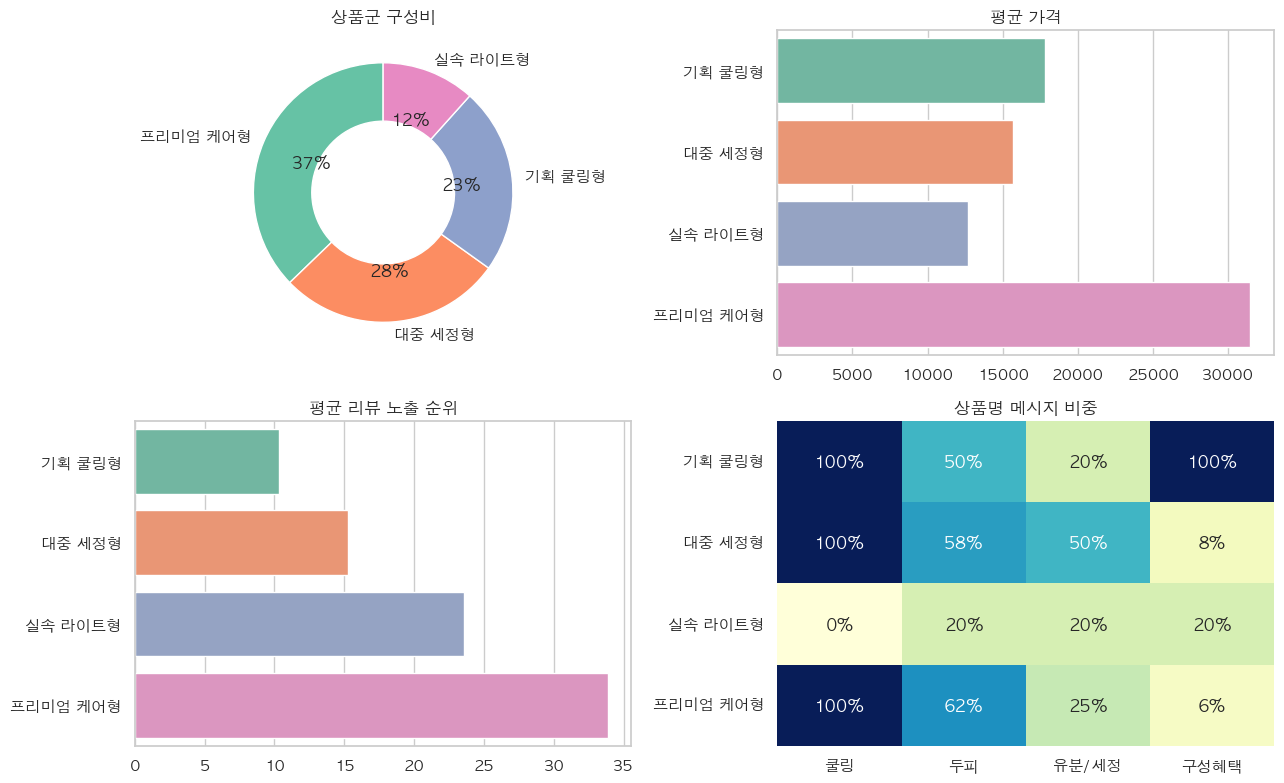

In [13]:
cluster_means = product_features.groupby("상품군", as_index=False)[["가격", "리뷰순위", "쿨링", "두피", "유분/세정", "구성혜택"]].mean()
product_group_counts = product_features["상품군"].value_counts()

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
axes[0, 0].pie(product_group_counts, labels=product_group_counts.index, autopct="%.0f%%", startangle=90, colors=sns.color_palette("Set2", len(product_group_counts)), wedgeprops={"width": 0.45})
sns.barplot(data=cluster_means, y="상품군", x="가격", ax=axes[0, 1], palette="Set2")
sns.barplot(data=cluster_means, y="상품군", x="리뷰순위", ax=axes[1, 0], palette="Set2")
sns.heatmap(cluster_means.set_index("상품군")[["쿨링", "두피", "유분/세정", "구성혜택"]], annot=True, fmt=".0%", cmap="YlGnBu", ax=axes[1, 1], cbar=False)

for ax, title in zip(axes.ravel(), ["상품군 구성비", "평균 가격", "평균 리뷰 노출 순위", "상품명 메시지 비중"]):
    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel("")

plt.tight_layout()
plt.show()

#### 요약

상품군은 리뷰 반응이 아니라 상품 분석 데이터를 기준으로 만들었습니다. 가격, 노출 순위, 상품명 메시지, 기획/구성 신호를 이용해 상품이 시장에서 어떤 포지션으로 제시되는지 먼저 나눴습니다.

이후 분석에서는 숫자 군집보다 `기획 쿨링형`, `대중 세정형`, `실속 라이트형`, `프리미엄 케어형`처럼 마케팅 관점의 상품군으로 비교합니다.

### 리뷰 텍스트 분석 데이터

#### 데이터 불러오기

04번에서 저장한 리뷰별 텍스트 분석 결과를 불러옵니다.

In [14]:
review_feature_path = "data/oliveyoung_cooling_shampoo_reviews_text_features.csv"
review_text_data = pd.read_csv(review_feature_path)

for col in join_keys:
    review_text_data[col] = review_text_data[col].astype(str).str.replace(r"\s+", " ", regex=True).str.strip()

review_text_data.head()

,브랜드,상품명,가격,가격대,옵션명,옵션혜택,리뷰내용,정제리뷰,키워드토큰문자열,리뷰평점,도움돼요구간,도움돼요점수,사진여부,리뷰글자수,리뷰단어수,리뷰군집,페르소나,주요관심사,대표키워드,메시지 방향,긍정신호여부,부정신호여부,쿨링감언급여부,향언급여부,두피언급여부,자극언급여부,가격구성언급여부,강한쿨링긍정여부,쿨링지속긍정여부,쿨링지속아쉬움여부,약한쿨링부족여부,민감자극회피여부
0,온더바디,온더바디 발을씻자 코튼 풋샴푸 리필 500ml 4종 택1 (레몬/자몽/쿨링/비누향),5950,1만원 미만,쿨링,일반,곰팡이까지 없애주는 발을 씻자!! 떨어지면 무조건 쟁여야 합니다,곰팡이까지 없애주는 발을 씻자 떨어지면 무조건 쟁여야 합니다,"곰팡, 없애주, 씻자, 떨어지면, 무조건, 쟁여야",5,매우 높음,4,False,35,8,1,실속 편의 탐색형,가격/구성/편의,"사용하기, 쓰고, 냄새, 않고, 드라이샴푸, 세정력, 지성, 있어서, 드라, 가루, 없어서, 재구매","용량 대비 가격, 구성 혜택, 사용 편의, 재구매 부담 감소를 전면에 배치",1,0,0,0,0,0,0,0,0,0,0,0
1,온더바디,온더바디 발을씻자 코튼 풋샴푸 리필 500ml 4종 택1 (레몬/자몽/쿨링/비누향),5950,1만원 미만,쿨링,일반,"여름 대비 필수템입니다. 발 전용 세정제라 처음에는 굳이 필요할까 싶었는데, 사용해보니 일반 바디워시와는 확실히 차이가 있었습니다. 스프레이 타입이라 손에 묻히지 않고 바로 발에 분사할 수 있어 간편하고 위생...",여름 대비 필수템입니다 발 전용 세정제라 처음에는 굳이 필요할까 싶었는데 사용해보니 일반 바디워시와는 확실히 차이가 있었습니다 스프레이 타입이라 손에 묻히지 않고 바로 발에 분사할 수 있어 간편하고 위생적으로...,"여름, 대비, 필수템, 전용, 세정제라, 필요할까, 싶었, 사용해보니, 일반, 바디워시, 확실히, 차이, 있었, 스프레, 타입, 묻히지, 않고, 분사할, 있어, 간편, 위생적, 사용할, 세정, 개운함, 오래,...",5,매우 높음,4,True,246,57,0,청량감 즉시 체감형,쿨링/열감,"여름, 사용하기, 거품, 있어서, 열감, 구매했, 시원해서, 용량, 시원한, 좋아, 쿨링제품, 사용할",시원함·개운함·상쾌함을 사용 직후 체감 언어로 제시,1,0,1,0,1,0,1,0,0,0,0,0
2,온더바디,온더바디 발을씻자 코튼 풋샴푸 리필 500ml 4종 택1 (레몬/자몽/쿨링/비누향),5950,1만원 미만,레몬,일반,🏷️사용감 분사하자마자 상큼달달한 자몽껌 향이 화장실에 확 퍼집니다 인위적이지 않아서 씻을 때마다 기분이 너무 좋아요 민트 성분 덕분에 다 씻고 나면 발이 엄청 시원합니다 🏷️장점 -분사형이라 허리 숙이지 않...,사용감 분사하자마자 상큼달달한 자몽껌 향이 화장실에 확 퍼집니다 인위적이지 않아서 씻을 때마다 기분이 너무 좋아요 민트 성분 덕분에 다 씻고 나면 발이 엄청 시원합니다 장점 분사형이라 허리 숙이지 않고도 발에...,"분사하자마자, 상큼달달한, 자몽껌, 화장실, 퍼집니다, 인위적이지, 않아서, 때마다, 기분, 민트, 성분, 덕분, 씻고, 나면, 장점, 분사형, 허리, 숙이지, 않고, 뿌려서, 씻기, 거품, 나서, 간단히, ...",5,매우 높음,4,True,288,71,2,세정감 꼼꼼 확인형,세정/거품,"거품, 세정력, 풍성하게, 샴푸바, 나고, 나서, 풍성, 생각, 좋았, 세정, 오래, 꾸준히",풍성한 거품·세정력·감은 뒤 머릿결을 실제 사용 장면으로 보여주기,1,0,1,1,0,0,0,1,0,0,0,0
3,온더바디,온더바디 발을씻자 코튼 풋샴푸 리필 500ml 4종 택1 (레몬/자몽/쿨링/비누향),5950,1만원 미만,쿨링,일반,비누체로 하기에는 귀찮아서 스프레이로 보드리면 간편해서 샀어요. 시원해요.,비누체로 하기에는 귀찮아서 스프레이로 보드리면 간편해서 샀어요 시원해요,"비누체, 하기, 귀찮아서, 스프레이, 보드리면, 간편해서",5,매우 높음,4,True,41,8,1,실속 편의 탐색형,가격/구성/편의,"사용하기, 쓰고, 냄새, 않고, 드라이샴푸, 세정력, 지성, 있어서, 드라, 가루, 없어서, 재구매","용량 대비 가격, 구성 혜택, 사용 편의, 재구매 부담 감소를 전면에 배치",1,0,1,0,0,0,0,0,0,0,0,0
4,온더바디,온더바디 발을씻자 코튼 풋샴푸 리필 500ml 4종 택1 (레몬/자몽/쿨링/비누향),5950,1만원 미만,레몬,일반,다른 향들 전부 사용해봤는데 뭐니뭐니해도 오리지널이 최고인 것 같습니다! 발체취가 완전 줄고 칙칙 뿌려서 사용하는 거다보니까 너무 좋더라고요!,다른 향들 전부 사용해봤는데 뭐니뭐니해도 오리지널이 최고인 것 같습니다 발체취가 완전 줄고 칙칙 뿌려서 사용하는 거다보니까 너무 좋더라고요,"다른, 향들, 전부, 사용해봤, 뭐니뭐니해, 오리지널, 최고인, 발체취, 줄고, 칙칙, 뿌려서, 사용하, 거다보니까, 좋더라",5,매우 높음,4,False,79,18,1,실속 편의 탐색형,가격/구성/편의,"사용하기, 쓰고, 냄새, 않고, 드라이샴푸, 세정력, 지성, 있어서, 드라, 가루, 없어서, 재구매","용량 대비 가격, 구성 혜택, 사용 편의, 재구매 부담 감소를 전면에 배치",0,0,0,1,0,0,0,0,0,0,0,0


#### 구조 확인

`info()`로 리뷰 단위 데이터의 컬럼 구성과 결측 여부를 확인합니다.

In [15]:
review_text_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 644 entries, 0 to 643
Data columns (total 32 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   브랜드        644 non-null    object
 1   상품명        644 non-null    object
 2   가격         644 non-null    int64 
 3   가격대        644 non-null    object
 4   옵션명        644 non-null    object
 5   옵션혜택       644 non-null    object
 6   리뷰내용       644 non-null    object
 7   정제리뷰       644 non-null    object
 8   키워드토큰문자열   644 non-null    object
 9   리뷰평점       644 non-null    int64 
 10  도움돼요구간     644 non-null    object
 11  도움돼요점수     644 non-null    int64 
 12  사진여부       644 non-null    bool  
 13  리뷰글자수      644 non-null    int64 
 14  리뷰단어수      644 non-null    int64 
 15  리뷰군집       644 non-null    int64 
 16  페르소나       644 non-null    object
 17  주요관심사      644 non-null    object
 18  대표키워드      644 non-null    object
 19  메시지 방향     644 non-null    object
 20  긍정신호여부     644 non-null    int64

#### 내용 확인

`head()`로 리뷰 원문과 텍스트 분석 컬럼의 실제 값 형태를 확인합니다.

In [16]:
review_preview_cols = [
    "브랜드", "상품명", "리뷰평점", "리뷰내용", "페르소나", "긍정신호여부", "부정신호여부"
]

review_text_data[review_preview_cols].head()

,브랜드,상품명,리뷰평점,리뷰내용,페르소나,긍정신호여부,부정신호여부
0,온더바디,온더바디 발을씻자 코튼 풋샴푸 리필 500ml 4종 택1 (레몬/자몽/쿨링/비누향),5,곰팡이까지 없애주는 발을 씻자!! 떨어지면 무조건 쟁여야 합니다,실속 편의 탐색형,1,0
1,온더바디,온더바디 발을씻자 코튼 풋샴푸 리필 500ml 4종 택1 (레몬/자몽/쿨링/비누향),5,"여름 대비 필수템입니다. 발 전용 세정제라 처음에는 굳이 필요할까 싶었는데, 사용해보니 일반 바디워시와는 확실히 차이가 있었습니다. 스프레이 타입이라 손에 묻히지 않고 바로 발에 분사할 수 있어 간편하고 위생...",청량감 즉시 체감형,1,0
2,온더바디,온더바디 발을씻자 코튼 풋샴푸 리필 500ml 4종 택1 (레몬/자몽/쿨링/비누향),5,🏷️사용감 분사하자마자 상큼달달한 자몽껌 향이 화장실에 확 퍼집니다 인위적이지 않아서 씻을 때마다 기분이 너무 좋아요 민트 성분 덕분에 다 씻고 나면 발이 엄청 시원합니다 🏷️장점 -분사형이라 허리 숙이지 않...,세정감 꼼꼼 확인형,1,0
3,온더바디,온더바디 발을씻자 코튼 풋샴푸 리필 500ml 4종 택1 (레몬/자몽/쿨링/비누향),5,비누체로 하기에는 귀찮아서 스프레이로 보드리면 간편해서 샀어요. 시원해요.,실속 편의 탐색형,1,0
4,온더바디,온더바디 발을씻자 코튼 풋샴푸 리필 500ml 4종 택1 (레몬/자몽/쿨링/비누향),5,다른 향들 전부 사용해봤는데 뭐니뭐니해도 오리지널이 최고인 것 같습니다! 발체취가 완전 줄고 칙칙 뿌려서 사용하는 거다보니까 너무 좋더라고요!,실속 편의 탐색형,0,0


### 통합 데이터 기준 확인

두 데이터의 크기와 상품 수를 비교해 통합 분석 기준을 확인합니다.

In [17]:
print(f"상품 분석 데이터: {len(product_data):,}행, {product_data.shape[1]:,}개 컬럼")
print(f"- 브랜드 수: {product_data['브랜드'].nunique():,}개")
print(f"- 상품 수: {product_data['상품명'].nunique():,}개")

print()
print(f"리뷰 텍스트 분석 데이터: {len(review_text_data):,}행, {review_text_data.shape[1]:,}개 컬럼")
print(f"- 브랜드 수: {review_text_data['브랜드'].nunique():,}개")
print(f"- 상품 수: {review_text_data['상품명'].nunique():,}개")
print(f"- 페르소나 수: {review_text_data['페르소나'].nunique():,}개")

상품 분석 데이터: 43행, 8개 컬럼
- 브랜드 수: 29개
- 상품 수: 43개

리뷰 텍스트 분석 데이터: 644행, 32개 컬럼
- 브랜드 수: 26개
- 상품 수: 38개
- 페르소나 수: 4개


## 3. 통합 데이터 준비

02번에서 저장한 상품 분석 데이터와 04번에서 저장한 리뷰 텍스트 분석 결과를 연결합니다.
가격, 가격대, 리뷰순위, 상품군은 상품 분석 데이터 기준으로 붙이고, 페르소나와 긍정/부정 신호는 리뷰 텍스트 분석 결과를 사용합니다.

### 상품-리뷰 텍스트 분석 결과 조인

In [18]:
print(f"조인 키: {', '.join(join_keys)}")
print(f"상품 분석 데이터 상품 수: {product_features[join_keys].drop_duplicates().shape[0]:,}개")
print(f"상품군 중복 키 수: {product_features.duplicated(join_keys).sum():,}개")
print(f"리뷰 데이터 상품 수: {review_text_data[join_keys].drop_duplicates().shape[0]:,}개")

조인 키: 브랜드, 상품명
상품 분석 데이터 상품 수: 43개
상품군 중복 키 수: 0개
리뷰 데이터 상품 수: 38개


In [19]:
product_meta_cols = ["브랜드", "상품명", "가격", "가격대", "리뷰순위", "페이지", "상품URL", "상품군집", "상품군"]
product_meta = product_features[product_meta_cols].drop_duplicates(join_keys)
review_for_merge = review_text_data.drop(columns=["가격", "가격대"], errors="ignore")

df = review_for_merge.merge(product_meta, on=join_keys, how="left", validate="many_to_one")
missing_product_count = df["상품군"].isna().sum()

# 상품 정보가 연결되지 않은 리뷰는 상품군, 가격대, 상품 메시지 비교가 불가능하므로 분석 대상에서 제외합니다.
df = df[df["상품군"].notna()].copy()

df.head()

,브랜드,상품명,옵션명,옵션혜택,리뷰내용,정제리뷰,키워드토큰문자열,리뷰평점,도움돼요구간,도움돼요점수,사진여부,리뷰글자수,리뷰단어수,리뷰군집,페르소나,주요관심사,대표키워드,메시지 방향,긍정신호여부,부정신호여부,쿨링감언급여부,향언급여부,두피언급여부,자극언급여부,가격구성언급여부,강한쿨링긍정여부,쿨링지속긍정여부,쿨링지속아쉬움여부,약한쿨링부족여부,민감자극회피여부,가격,가격대,리뷰순위,페이지,상품URL,상품군집,상품군
0,온더바디,온더바디 발을씻자 코튼 풋샴푸 리필 500ml 4종 택1 (레몬/자몽/쿨링/비누향),쿨링,일반,곰팡이까지 없애주는 발을 씻자!! 떨어지면 무조건 쟁여야 합니다,곰팡이까지 없애주는 발을 씻자 떨어지면 무조건 쟁여야 합니다,"곰팡, 없애주, 씻자, 떨어지면, 무조건, 쟁여야",5,매우 높음,4,False,35,8,1,실속 편의 탐색형,가격/구성/편의,"사용하기, 쓰고, 냄새, 않고, 드라이샴푸, 세정력, 지성, 있어서, 드라, 가루, 없어서, 재구매","용량 대비 가격, 구성 혜택, 사용 편의, 재구매 부담 감소를 전면에 배치",1,0,0,0,0,0,0,0,0,0,0,0,5950,1만원 미만,1,1,https://www.oliveyoung.co.kr/store/goods/getGoodsDetail.do?goodsNo=A000000186445&dispCatNo=1000001000300240002&track...,0,기획 쿨링형
1,온더바디,온더바디 발을씻자 코튼 풋샴푸 리필 500ml 4종 택1 (레몬/자몽/쿨링/비누향),쿨링,일반,"여름 대비 필수템입니다. 발 전용 세정제라 처음에는 굳이 필요할까 싶었는데, 사용해보니 일반 바디워시와는 확실히 차이가 있었습니다. 스프레이 타입이라 손에 묻히지 않고 바로 발에 분사할 수 있어 간편하고 위생...",여름 대비 필수템입니다 발 전용 세정제라 처음에는 굳이 필요할까 싶었는데 사용해보니 일반 바디워시와는 확실히 차이가 있었습니다 스프레이 타입이라 손에 묻히지 않고 바로 발에 분사할 수 있어 간편하고 위생적으로...,"여름, 대비, 필수템, 전용, 세정제라, 필요할까, 싶었, 사용해보니, 일반, 바디워시, 확실히, 차이, 있었, 스프레, 타입, 묻히지, 않고, 분사할, 있어, 간편, 위생적, 사용할, 세정, 개운함, 오래,...",5,매우 높음,4,True,246,57,0,청량감 즉시 체감형,쿨링/열감,"여름, 사용하기, 거품, 있어서, 열감, 구매했, 시원해서, 용량, 시원한, 좋아, 쿨링제품, 사용할",시원함·개운함·상쾌함을 사용 직후 체감 언어로 제시,1,0,1,0,1,0,1,0,0,0,0,0,5950,1만원 미만,1,1,https://www.oliveyoung.co.kr/store/goods/getGoodsDetail.do?goodsNo=A000000186445&dispCatNo=1000001000300240002&track...,0,기획 쿨링형
2,온더바디,온더바디 발을씻자 코튼 풋샴푸 리필 500ml 4종 택1 (레몬/자몽/쿨링/비누향),레몬,일반,🏷️사용감 분사하자마자 상큼달달한 자몽껌 향이 화장실에 확 퍼집니다 인위적이지 않아서 씻을 때마다 기분이 너무 좋아요 민트 성분 덕분에 다 씻고 나면 발이 엄청 시원합니다 🏷️장점 -분사형이라 허리 숙이지 않...,사용감 분사하자마자 상큼달달한 자몽껌 향이 화장실에 확 퍼집니다 인위적이지 않아서 씻을 때마다 기분이 너무 좋아요 민트 성분 덕분에 다 씻고 나면 발이 엄청 시원합니다 장점 분사형이라 허리 숙이지 않고도 발에...,"분사하자마자, 상큼달달한, 자몽껌, 화장실, 퍼집니다, 인위적이지, 않아서, 때마다, 기분, 민트, 성분, 덕분, 씻고, 나면, 장점, 분사형, 허리, 숙이지, 않고, 뿌려서, 씻기, 거품, 나서, 간단히, ...",5,매우 높음,4,True,288,71,2,세정감 꼼꼼 확인형,세정/거품,"거품, 세정력, 풍성하게, 샴푸바, 나고, 나서, 풍성, 생각, 좋았, 세정, 오래, 꾸준히",풍성한 거품·세정력·감은 뒤 머릿결을 실제 사용 장면으로 보여주기,1,0,1,1,0,0,0,1,0,0,0,0,5950,1만원 미만,1,1,https://www.oliveyoung.co.kr/store/goods/getGoodsDetail.do?goodsNo=A000000186445&dispCatNo=1000001000300240002&track...,0,기획 쿨링형
3,온더바디,온더바디 발을씻자 코튼 풋샴푸 리필 500ml 4종 택1 (레몬/자몽/쿨링/비누향),쿨링,일반,비누체로 하기에는 귀찮아서 스프레이로 보드리면 간편해서 샀어요. 시원해요.,비누체로 하기에는 귀찮아서 스프레이로 보드리면 간편해서 샀어요 시원해요,"비누체, 하기, 귀찮아서, 스프레이, 보드리면, 간편해서",5,매우 높음,4,True,41,8,1,실속 편의 탐색형,가격/구성/편의,"사용하기, 쓰고, 냄새, 않고, 드라이샴푸, 세정력, 지성, 있어서, 드라, 가루, 없어서, 재구매","용량 대비 가격, 구성 혜택, 사용 편의, 재구매 부담 감소를 전면에 배치",1,0,1,0,0,0,0,0,0,0,0,0,5950,1만원 미만,1,1,https://www.oliveyoung.co.kr/store/goods/getGoodsDetail.do?goodsNo=A000000186445&dispCatNo=1000001000300240002&track...,0,기획 쿨링형
4,온더바디,온더바디 발을씻자 코튼 풋샴푸 리필 500ml 4종 택1 (레몬/자몽/쿨링/비누향),레몬,일반,다른 향들 전부 사용해봤는데 뭐니뭐니해도 오리지널이 최고인 것 같습니다! 발체취가 완전 줄고 칙칙 뿌려서 사용하는 거다보니까 너무 좋더라고요!,다른 향들 전부 사용해봤는데 뭐니뭐니해도 오리지널이 최고인 것 같습니다 발체취가 완전 줄고 칙칙 뿌려서 사용하는 거다보니까 너무 좋더라고요,"다른, 향들, 전부, 사용해봤, 뭐니뭐니해, 오리지널, 최고인, 발체취, 줄고, 칙칙, 뿌려서, 사용하, 거다보니까, 좋더라",5,매우 높음,4,False,79,18,1,실속 편의 탐색형,가격/구성/편의,"사용하기, 쓰고, 냄새, 않고, 드라이샴푸, 세정력, 지성, 있어서, 드라, 가루, 없어서, 재구매","용량 대비 가격, 구성 혜택, 사용 편의, 재구매 부담 감소를 전면에 배치",0,0,0,1,0,0,0,0,0,0,0,0,5950,1만원 미만,1,1,https://www.oliveyoung.co.kr/store/goods/getGoodsDetail.do?goodsNo=A000000186445&dispCatNo=1000001000300240002&track...,0,기획 쿨링형


In [20]:
print(f"조인 전 리뷰 수: {len(review_text_data):,}개")
print(f"상품 정보 미연결 리뷰 수: {missing_product_count:,}개")
print(f"분석에 사용할 리뷰 수: {len(df):,}개")

조인 전 리뷰 수: 644개
상품 정보 미연결 리뷰 수: 0개
분석에 사용할 리뷰 수: 644개


### 통합 데이터 품질 확인

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 644 entries, 0 to 643
Data columns (total 37 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   브랜드        644 non-null    object
 1   상품명        644 non-null    object
 2   옵션명        644 non-null    object
 3   옵션혜택       644 non-null    object
 4   리뷰내용       644 non-null    object
 5   정제리뷰       644 non-null    object
 6   키워드토큰문자열   644 non-null    object
 7   리뷰평점       644 non-null    int64 
 8   도움돼요구간     644 non-null    object
 9   도움돼요점수     644 non-null    int64 
 10  사진여부       644 non-null    bool  
 11  리뷰글자수      644 non-null    int64 
 12  리뷰단어수      644 non-null    int64 
 13  리뷰군집       644 non-null    int64 
 14  페르소나       644 non-null    object
 15  주요관심사      644 non-null    object
 16  대표키워드      644 non-null    object
 17  메시지 방향     644 non-null    object
 18  긍정신호여부     644 non-null    int64 
 19  부정신호여부     644 non-null    int64 
 20  쿨링감언급여부    644 non-null    int64

In [22]:
check_cols = [
    "브랜드", "상품명", "상품군", "가격", "가격대", "옵션혜택", "리뷰평점",
    "도움돼요점수", "페르소나", "긍정신호여부", "부정신호여부",
]

print(f"주요 분석 컬럼 결측치 수: {df[check_cols].isna().sum().sum():,}개")
print(f"중복 리뷰 수: {df.duplicated(['브랜드', '상품명', '리뷰내용']).sum():,}개")
print(f"상품군 결측 리뷰 수: {df['상품군'].isna().sum():,}개")

주요 분석 컬럼 결측치 수: 0개
중복 리뷰 수: 0개
상품군 결측 리뷰 수: 0개


## 4. 통합 데이터 전처리

EDA에서 바로 사용할 신호 컬럼과 짧은 라벨만 정리합니다.

### 분석용 신호 컬럼 정리

In [23]:
df = df.copy()
df["유분세정언급여부"] = (
    df["정제리뷰"].fillna("").str.contains(r"유분|기름|정수리|떡짐|피지|세정|노세범|개운", regex=True).astype(int)
)

signal_cols = [col for col in df.columns if col.endswith("여부")]

print("[전처리 전]")
print(df[signal_cols].dtypes.value_counts())

df[signal_cols] = df[signal_cols].fillna(0).astype(int)

print()
print("[전처리 후]")
print(df[signal_cols].dtypes.value_counts())

[전처리 전]
int64    13
bool      1
Name: count, dtype: int64

[전처리 후]
int64    14
Name: count, dtype: int64


### 리뷰 신호 라벨 정리

In [24]:
print("[전처리 전]")
print(df[["긍정신호여부", "부정신호여부"]].value_counts())

df["긍정"] = df["긍정신호여부"].map({1: "O", 0: "X"})
df["부정"] = df["부정신호여부"].map({1: "O", 0: "X"})

print("\n[전처리 후]")
df[["긍정", "부정"]].value_counts().reset_index(name="리뷰수")

[전처리 전]
긍정신호여부  부정신호여부
1       0         320
        1         196
0       0         106
        1          22
Name: count, dtype: int64

[전처리 후]


,긍정,부정,리뷰수
0,O,X,320
1,O,O,196
2,X,X,106
3,X,O,22


### 전처리 결과 확인

In [25]:
preview_cols = [
    "브랜드", "상품명", "상품군", "가격", "가격대", "옵션혜택", "리뷰평점", "페르소나", "긍정", "부정",
]

df[preview_cols].head()

,브랜드,상품명,상품군,가격,가격대,옵션혜택,리뷰평점,페르소나,긍정,부정
0,온더바디,온더바디 발을씻자 코튼 풋샴푸 리필 500ml 4종 택1 (레몬/자몽/쿨링/비누향),기획 쿨링형,5950,1만원 미만,일반,5,실속 편의 탐색형,O,X
1,온더바디,온더바디 발을씻자 코튼 풋샴푸 리필 500ml 4종 택1 (레몬/자몽/쿨링/비누향),기획 쿨링형,5950,1만원 미만,일반,5,청량감 즉시 체감형,O,X
2,온더바디,온더바디 발을씻자 코튼 풋샴푸 리필 500ml 4종 택1 (레몬/자몽/쿨링/비누향),기획 쿨링형,5950,1만원 미만,일반,5,세정감 꼼꼼 확인형,O,X
3,온더바디,온더바디 발을씻자 코튼 풋샴푸 리필 500ml 4종 택1 (레몬/자몽/쿨링/비누향),기획 쿨링형,5950,1만원 미만,일반,5,실속 편의 탐색형,O,X
4,온더바디,온더바디 발을씻자 코튼 풋샴푸 리필 500ml 4종 택1 (레몬/자몽/쿨링/비누향),기획 쿨링형,5950,1만원 미만,일반,5,실속 편의 탐색형,X,X


### 통합 데이터 저장 및 불러오기

조인과 전처리가 끝난 통합 데이터를 저장합니다.
이후 분석은 저장된 `oliveyoung_cooling_shampoo_integrated_data.csv`를 다시 불러온 데이터 기준으로 진행합니다.

In [26]:
df_path = "data/oliveyoung_cooling_shampoo_integrated_data.csv"

df.to_csv(df_path, index=False, encoding="utf-8-sig")
print(f"통합 데이터 저장 완료: {df_path}")
print(f"저장된 데이터 크기: {df.shape[0]:,}행, {df.shape[1]:,}컬럼")

통합 데이터 저장 완료: data/oliveyoung_cooling_shampoo_integrated_data.csv
저장된 데이터 크기: 644행, 40컬럼


저장한 통합 데이터를 다시 불러와 분석 기준 데이터로 사용합니다.

In [27]:
df = pd.read_csv(df_path)

print(f"불러온 통합 데이터 크기: {df.shape[0]:,}행, {df.shape[1]:,}컬럼")
print(f"상품군 결측 리뷰 수: {df['상품군'].isna().sum():,}개")
df[preview_cols].head()

불러온 통합 데이터 크기: 644행, 40컬럼
상품군 결측 리뷰 수: 0개


,브랜드,상품명,상품군,가격,가격대,옵션혜택,리뷰평점,페르소나,긍정,부정
0,온더바디,온더바디 발을씻자 코튼 풋샴푸 리필 500ml 4종 택1 (레몬/자몽/쿨링/비누향),기획 쿨링형,5950,1만원 미만,일반,5,실속 편의 탐색형,O,X
1,온더바디,온더바디 발을씻자 코튼 풋샴푸 리필 500ml 4종 택1 (레몬/자몽/쿨링/비누향),기획 쿨링형,5950,1만원 미만,일반,5,청량감 즉시 체감형,O,X
2,온더바디,온더바디 발을씻자 코튼 풋샴푸 리필 500ml 4종 택1 (레몬/자몽/쿨링/비누향),기획 쿨링형,5950,1만원 미만,일반,5,세정감 꼼꼼 확인형,O,X
3,온더바디,온더바디 발을씻자 코튼 풋샴푸 리필 500ml 4종 택1 (레몬/자몽/쿨링/비누향),기획 쿨링형,5950,1만원 미만,일반,5,실속 편의 탐색형,O,X
4,온더바디,온더바디 발을씻자 코튼 풋샴푸 리필 500ml 4종 택1 (레몬/자몽/쿨링/비누향),기획 쿨링형,5950,1만원 미만,일반,5,실속 편의 탐색형,X,X


## 5-3. 상품 메시지와 소비자 경험 비교

이제 상품군, 브랜드, 가격대, 옵션혜택, 상품명 메시지가 실제 소비자 경험과 어떻게 연결되는지 확인합니다.
분석의 초점은 `무엇이 좋은 반응을 만들었는가`, `어떤 소비자가 어떤 상품을 선택했는가`입니다.

### 소비자는 어떤 경험에 반응했는가

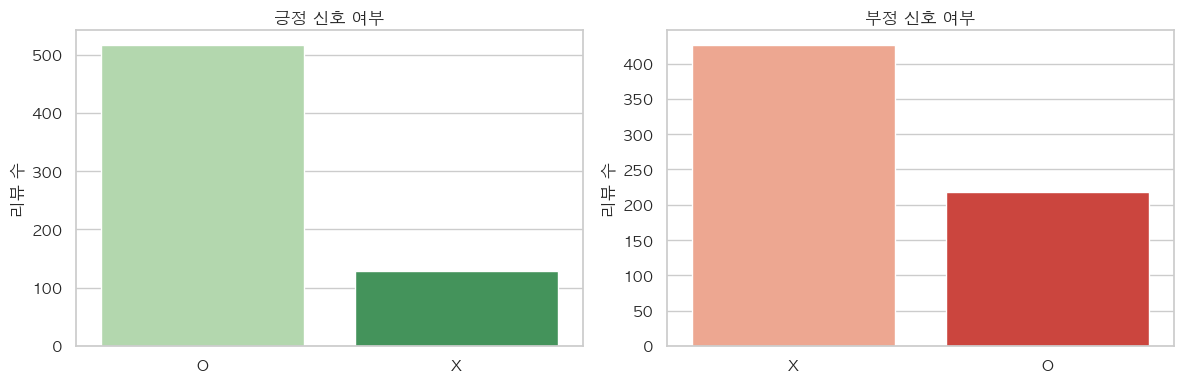

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(data=df, x="긍정", ax=axes[0], palette="Greens")
sns.countplot(data=df, x="부정", ax=axes[1], palette="Reds")
axes[0].set_title("긍정 신호 여부")
axes[1].set_title("부정 신호 여부")
for ax in axes:
    ax.set_xlabel("")
    ax.set_ylabel("리뷰 수")
plt.tight_layout()
plt.show()

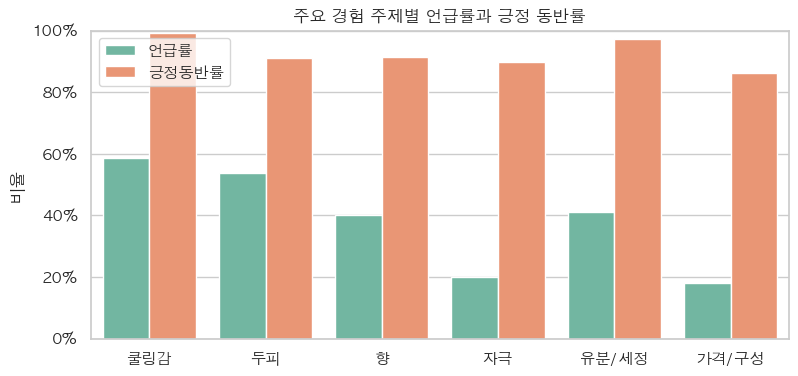

In [29]:
topic_map = {
    "쿨링감": "쿨링감언급여부", "두피": "두피언급여부", "향": "향언급여부",
    "자극": "자극언급여부", "유분/세정": "유분세정언급여부", "가격/구성": "가격구성언급여부",
}

topic_summary = pd.DataFrame({
    "경험주제": topic_map.keys(),
    "언급률": [df[col].mean() for col in topic_map.values()],
    "긍정동반률": [df.loc[df[col] == 1, "긍정신호여부"].mean() for col in topic_map.values()],
})

plt.figure(figsize=(9, 4))
sns.barplot(data=topic_summary.melt("경험주제", var_name="지표", value_name="비율"), x="경험주제", y="비율", hue="지표", palette="Set2")
plt.title("주요 경험 주제별 언급률과 긍정 동반률")
plt.xlabel("")
plt.ylabel("비율")
plt.ylim(0, 1)
set_percent_axis(plt.gca(), "y")
plt.legend(title="")
plt.show()

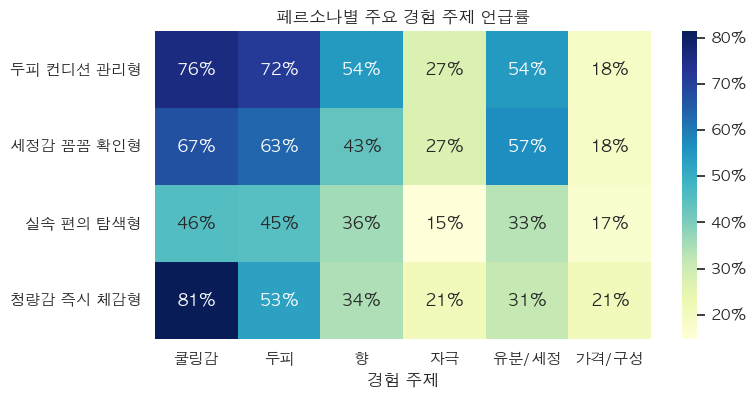

In [30]:
persona_topic = df.groupby("페르소나")[list(topic_map.values())].mean()
persona_topic.columns = topic_map.keys()

plt.figure(figsize=(8, 4))
draw_percent_heatmap(persona_topic, "페르소나별 주요 경험 주제 언급률", "YlGnBu")
plt.xlabel("경험 주제")
plt.ylabel("")
plt.show()

#### 요약

리뷰 반응은 `쿨링` 하나로만 설명되지 않았고, 두피 컨디션·향·자극 경험까지 함께 움직였습니다. 긍정 신호가 많지만, 긍정과 부정이 함께 나타난 리뷰도 있어 만족 포인트와 불안 요소를 같이 봐야 합니다.<br><br>
<strong>진입 메시지는 시원함, 설득 메시지는 페르소나별 불안 해소로 나누는 방향이 맞습니다.</strong> 두피 진정, 향 사용감, 민감 두피 안심 포인트를 소비자 유형에 맞게 나누어 보여주는 구조가 필요합니다.

### 브랜드는 어떤 소비자를 타깃팅하고 있는가

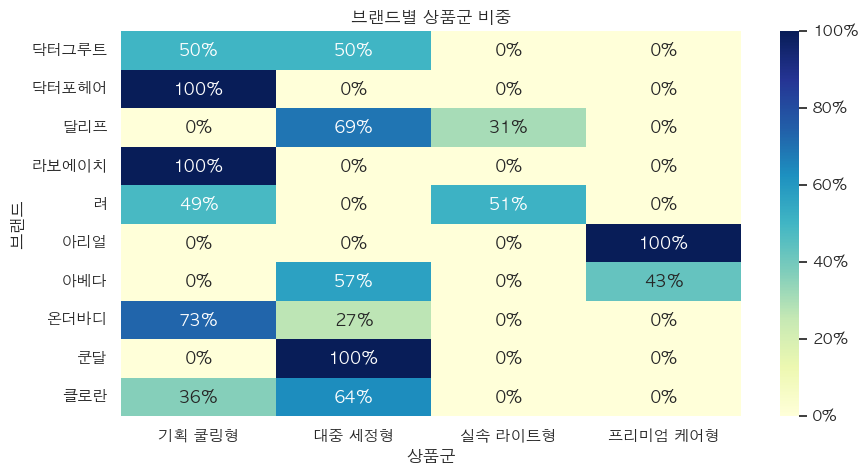

In [31]:
top_brands = df["브랜드"].value_counts().head(10).index
brand_data = df[df["브랜드"].isin(top_brands)]

brand_group = pd.crosstab(brand_data["브랜드"], brand_data["상품군"], normalize="index")
plt.figure(figsize=(10, 5))
draw_percent_heatmap(brand_group, "브랜드별 상품군 비중", "YlGnBu")
plt.xlabel("상품군")
plt.ylabel("브랜드")
plt.show()

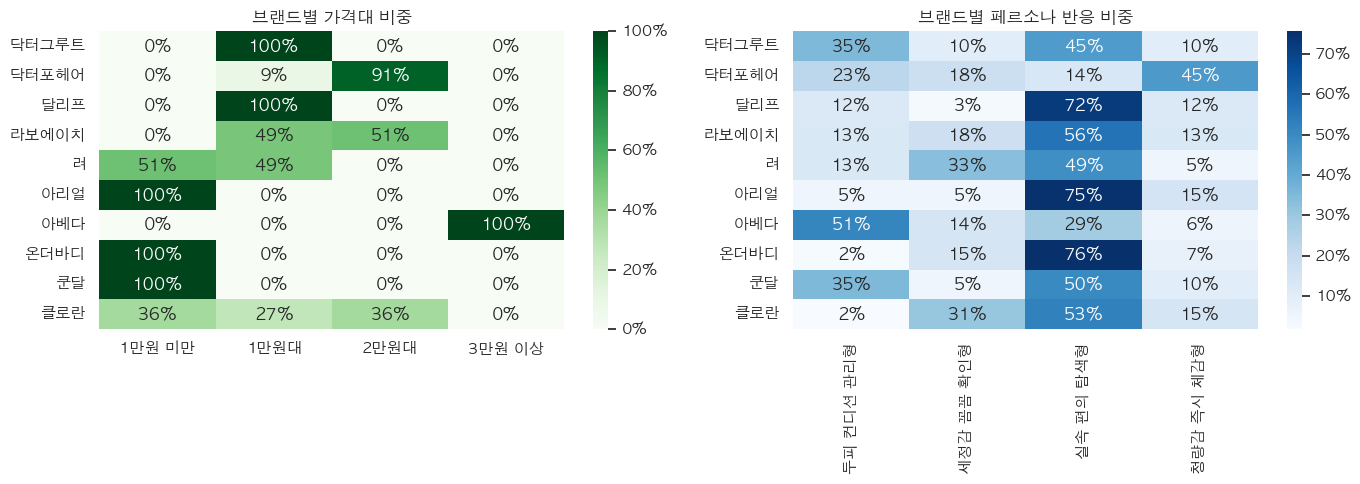

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
brand_price = pd.crosstab(brand_data["브랜드"], brand_data["가격대"], normalize="index")
brand_persona = pd.crosstab(brand_data["브랜드"], brand_data["페르소나"], normalize="index")

draw_percent_heatmap(brand_price, "브랜드별 가격대 비중", "Greens", axes[0])
draw_percent_heatmap(brand_persona, "브랜드별 페르소나 반응 비중", "Blues", axes[1])
for ax in axes:
    ax.set_xlabel("")
    ax.set_ylabel("")
plt.tight_layout()
plt.show()

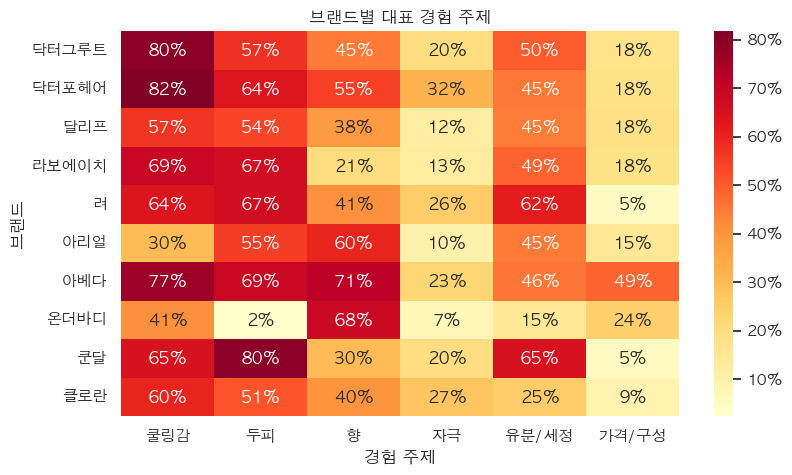

In [33]:
brand_topic = brand_data.groupby("브랜드")[list(topic_map.values())].mean()
brand_topic.columns = topic_map.keys()

plt.figure(figsize=(9, 5))
draw_percent_heatmap(brand_topic, "브랜드별 대표 경험 주제", "YlOrRd")
plt.xlabel("경험 주제")
plt.ylabel("브랜드")
plt.show()

#### 요약

브랜드별로 많이 연결된 상품군과 페르소나가 달라 타깃 포지션이 나뉘었습니다. 라보에이치·클로란처럼 특정 상품군에 리뷰가 집중된 브랜드는 대표 경험을 명확히 앞세울 수 있습니다.<br><br>
<strong>여러 상품군에 걸친 브랜드는 하나의 메시지로 묶기보다 소비자 유형별 랜딩 메시지를 나눠 운영하는 전략이 맞습니다.</strong>

### 가격과 옵션은 소비자 반응을 바꾸는가

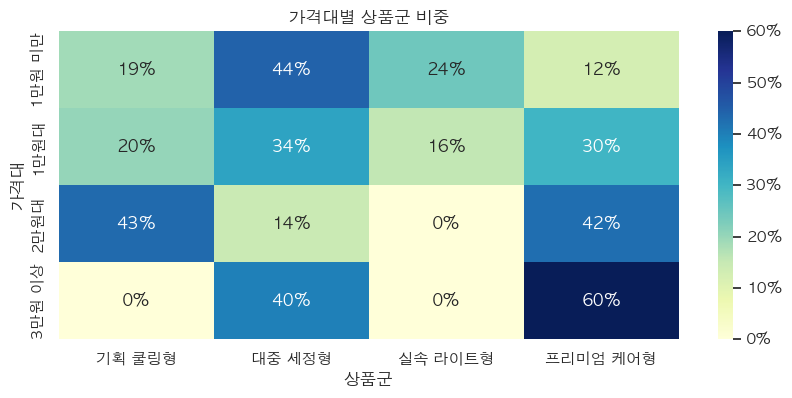

In [34]:
price_group = pd.crosstab(df["가격대"], df["상품군"], normalize="index")
plt.figure(figsize=(10, 4))
draw_percent_heatmap(price_group, "가격대별 상품군 비중", "YlGnBu")
plt.xlabel("상품군")
plt.ylabel("가격대")
plt.show()

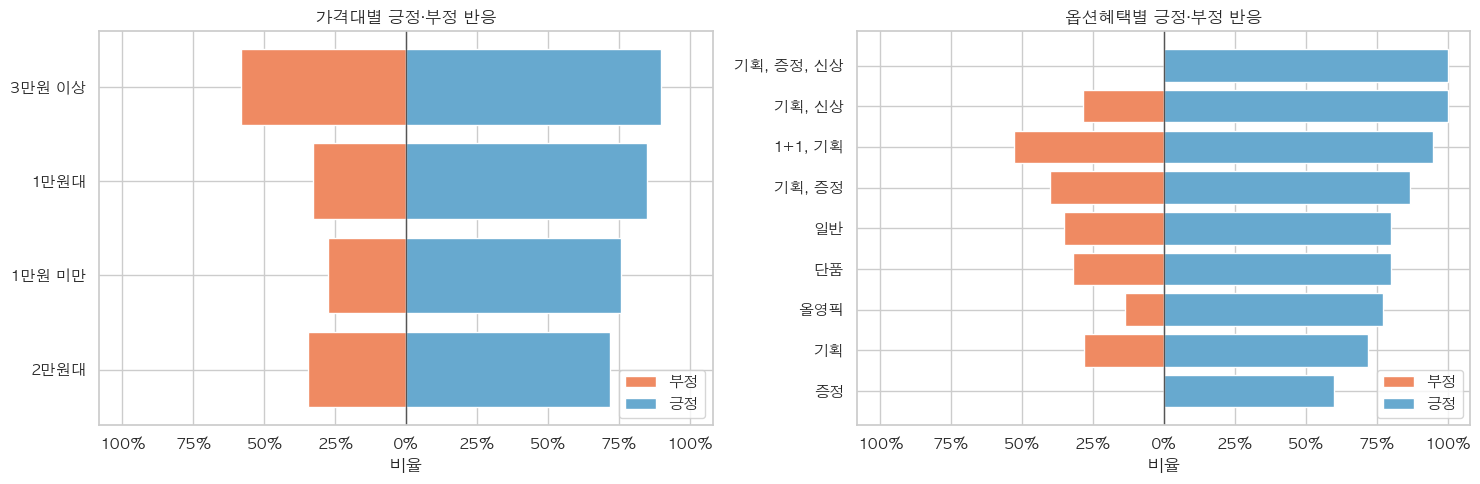

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
price_signal = df.groupby("가격대", as_index=False)[["긍정신호여부", "부정신호여부"]].mean()
option_signal = df.groupby("옵션혜택", as_index=False)[["긍정신호여부", "부정신호여부"]].mean()

for ax, data, label_col, title in [
    (axes[0], price_signal, "가격대", "가격대별 긍정·부정 반응"),
    (axes[1], option_signal, "옵션혜택", "옵션혜택별 긍정·부정 반응"),
]:
    data = data.sort_values("긍정신호여부")
    ax.barh(data[label_col], -data["부정신호여부"], color="#ef8a62", label="부정")
    ax.barh(data[label_col], data["긍정신호여부"], color="#67a9cf", label="긍정")
    ax.axvline(0, color="#555555", linewidth=1)
    ax.set_xlim(-1.08, 1.08)
    ax.set_xticks(np.linspace(-1, 1, 9))
    ax.set_title(title)
    ax.set_xlabel("비율")
    ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{abs(x):.0%}"))
    ax.set_ylabel("")
    ax.legend(loc="lower right")

plt.tight_layout()
plt.show()

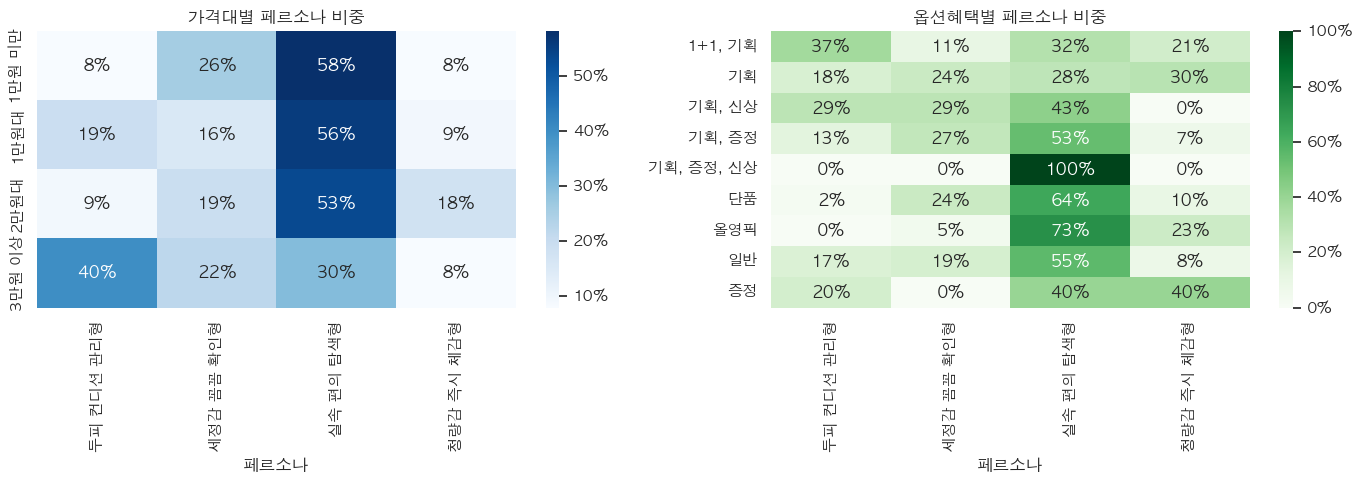

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
price_persona = pd.crosstab(df["가격대"], df["페르소나"], normalize="index")
option_persona = pd.crosstab(df["옵션혜택"], df["페르소나"], normalize="index")

draw_percent_heatmap(price_persona, "가격대별 페르소나 비중", "Blues", axes[0])
draw_percent_heatmap(option_persona, "옵션혜택별 페르소나 비중", "Greens", axes[1])
for ax in axes:
    ax.set_xlabel("페르소나")
    ax.set_ylabel("")
plt.tight_layout()
plt.show()

#### 요약

가격대와 옵션혜택은 소비자가 기대하는 효용을 다르게 만들었습니다. 1만원대는 가장 넓은 페르소나를 흡수하는 기본 가격축으로 볼 수 있습니다.<br><br>
<strong>고가 상품은 프리미엄 효능만 강조하기보다 기대 불일치 리스크를 줄이는 근거를 강화해야 합니다.</strong> 기획·증정·1+1은 가격 저항을 낮추는 장치로 쓰되, 단순 혜택보다 `왜 지금 사야 하는지`를 함께 제시하는 쪽으로 잡습니다.

### 상품명 메시지는 실제 리뷰 경험과 일치하는가

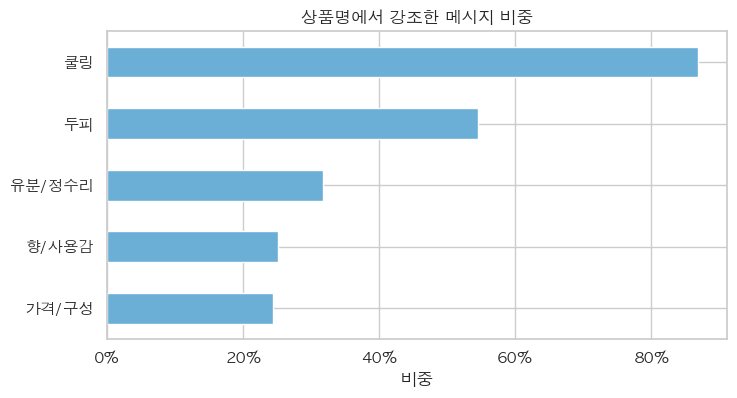

In [37]:
name_text = df["상품명"].fillna("")
message_patterns = {
    "쿨링": r"쿨링|쿨|민트|시원|청량",
    "두피": r"두피|탈모|스칼프|비듬|각질|가려움",
    "유분/정수리": r"유분|노세범|기름|정수리|드라이",
    "향/사용감": r"향|퍼퓸|로즈메리|아쿠아|프레시",
    "가격/구성": r"기획|증정|대용량|1\+1|리필|더블|세트",
}

message_flags = pd.DataFrame({label: name_text.str.contains(pattern, regex=True).astype(int) for label, pattern in message_patterns.items()})
message_flags.mean().sort_values().plot(kind="barh", figsize=(8, 4), color="#6baed6")
plt.title("상품명에서 강조한 메시지 비중")
plt.xlabel("비중")
set_percent_axis(plt.gca(), "x")
plt.ylabel("")
plt.show()

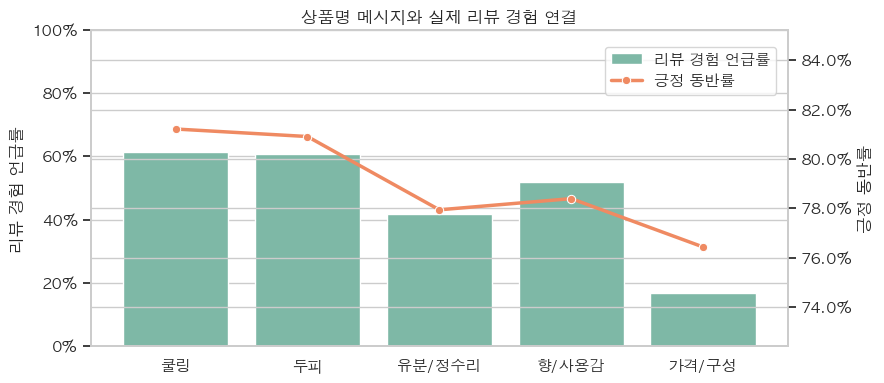

In [38]:
message_topic_pairs = {
    "쿨링": "쿨링감언급여부", "두피": "두피언급여부", "유분/정수리": "유분세정언급여부",
    "향/사용감": "향언급여부", "가격/구성": "가격구성언급여부",
}

message_match = []
for label, topic_col in message_topic_pairs.items():
    target = df[message_flags[label] == 1]
    message_match.append({"메시지": label, "리뷰 경험 언급률": target[topic_col].mean(), "긍정 동반률": target["긍정신호여부"].mean()})

message_match = pd.DataFrame(message_match)
fig, ax1 = plt.subplots(figsize=(9, 4))
sns.barplot(data=message_match, x="메시지", y="리뷰 경험 언급률", color="#74c2aa", ax=ax1)
ax1.set_title("상품명 메시지와 실제 리뷰 경험 연결")
ax1.set_xlabel("")
ax1.set_ylabel("리뷰 경험 언급률")
ax1.set_ylim(0, 1)
set_percent_axis(ax1, "y")

ax2 = ax1.twinx()
sns.lineplot(data=message_match, x="메시지", y="긍정 동반률", marker="o", linewidth=2.5, color="#ef8a62", ax=ax2)
ax2.set_ylabel("긍정 동반률")
positive_min = message_match["긍정 동반률"].min()
positive_max = message_match["긍정 동반률"].max()
ax2.set_ylim(max(0, positive_min - 0.04), min(1, positive_max + 0.04))
set_percent_axis(ax2, "y")

ax1.patches[0].set_label("리뷰 경험 언급률")
ax2.lines[0].set_label("긍정 동반률")
fig.legend(loc="upper right", bbox_to_anchor=(0.88, 0.88), frameon=True)
plt.tight_layout()
plt.show()

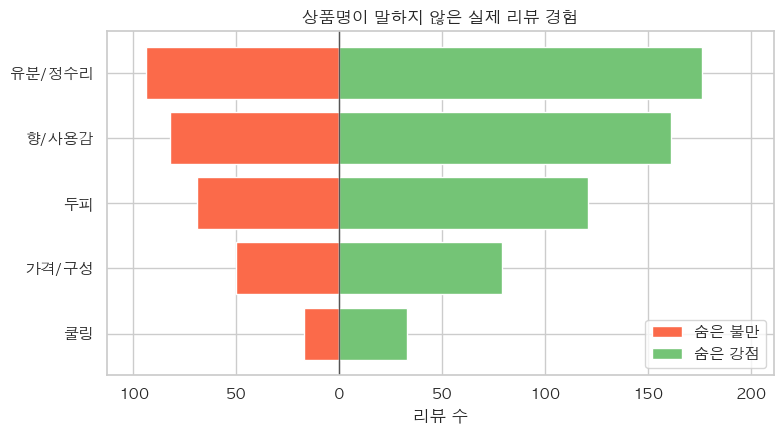

In [39]:
hidden_rows = []
for label, topic_col in message_topic_pairs.items():
    hidden = df[(message_flags[label] == 0) & (df[topic_col] == 1)]
    hidden_rows.append({"경험주제": label, "숨은 강점": hidden["긍정신호여부"].sum(), "숨은 불만": hidden["부정신호여부"].sum()})

hidden_summary = pd.DataFrame(hidden_rows).sort_values("숨은 강점")
plt.figure(figsize=(8, 4.5))
plt.barh(hidden_summary["경험주제"], -hidden_summary["숨은 불만"], color="#fb6a4a", label="숨은 불만")
plt.barh(hidden_summary["경험주제"], hidden_summary["숨은 강점"], color="#74c476", label="숨은 강점")
plt.axvline(0, color="#555555", linewidth=1)
plt.title("상품명이 말하지 않은 실제 리뷰 경험")
plt.xlabel("리뷰 수")
plt.ylabel("")
plt.xlim(-hidden_summary["숨은 불만"].max() * 1.2, hidden_summary["숨은 강점"].max() * 1.2)
plt.gca().xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{abs(int(x))}"))
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

#### 요약

상품명에서 강조한 메시지와 리뷰에서 반복된 경험이 맞는 축은 광고 카피로 바로 확장할 수 있습니다. 상품명이 말하지 않았는데 긍정 리뷰가 쌓인 경험은 숨은 강점입니다.<br><br>
<strong>숨은 강점은 상세페이지 상단 메시지 후보로 올리고, 부정 리뷰가 쌓인 경험은 구매 전 FAQ나 사용 가이드에서 먼저 해소해야 합니다.</strong>

### 어떤 소비자가 어떤 상품을 선택했는가

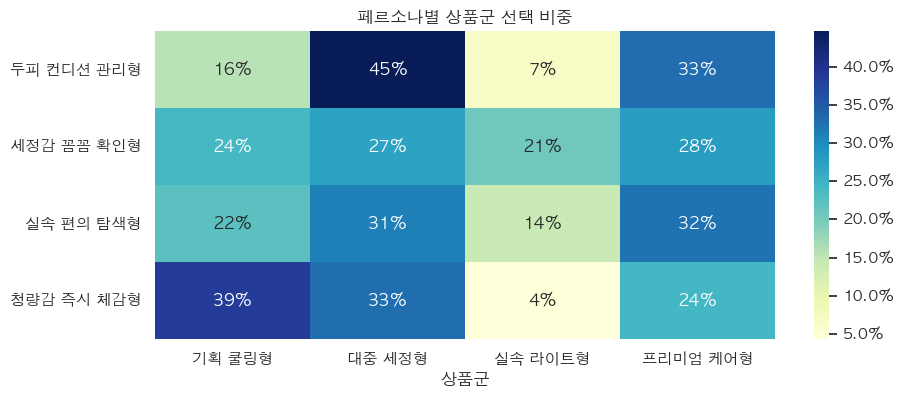

In [40]:
persona_group = pd.crosstab(df["페르소나"], df["상품군"], normalize="index")
plt.figure(figsize=(10, 4))
draw_percent_heatmap(persona_group, "페르소나별 상품군 선택 비중", "YlGnBu")
plt.xlabel("상품군")
plt.ylabel("")
plt.show()

#### 상품군에서 페르소나로 이어지는 긍정 반응 흐름

In [41]:
persona_product_flow = df.groupby(["상품군", "페르소나"], as_index=False).agg(
    리뷰수=("리뷰내용", "count"),
    긍정리뷰수=("긍정신호여부", "sum"),
    긍정비율=("긍정신호여부", "mean"),
)
persona_product_flow = persona_product_flow[persona_product_flow["긍정리뷰수"] > 0]

product_nodes = persona_product_flow["상품군"].drop_duplicates().tolist()
persona_nodes = persona_product_flow["페르소나"].drop_duplicates().tolist()
labels = product_nodes + persona_nodes
node_index = {name: idx for idx, name in enumerate(labels)}
persona_product_flow["상품군대표흐름"] = persona_product_flow["긍정리뷰수"] == persona_product_flow.groupby("상품군")["긍정리뷰수"].transform("max")
persona_product_flow["페르소나대표흐름"] = persona_product_flow["긍정리뷰수"] == persona_product_flow.groupby("페르소나")["긍정리뷰수"].transform("max")
persona_product_flow["대표구분"] = np.select(
    [persona_product_flow["상품군대표흐름"] & persona_product_flow["페르소나대표흐름"], persona_product_flow["상품군대표흐름"], persona_product_flow["페르소나대표흐름"]],
    ["상품군/페르소나 대표", "상품군 대표", "페르소나 대표"],
    default="기타 흐름",
)
link_colors = np.select(
    [persona_product_flow["상품군대표흐름"], persona_product_flow["페르소나대표흐름"]],
    ["rgba(116, 169, 207, 0.70)", "rgba(253, 174, 107, 0.70)"],
    default="rgba(170, 170, 170, 0.16)",
).tolist()

fig = go.Figure(go.Sankey(
    arrangement="snap",
    node=dict(
        label=labels,
        pad=18,
        thickness=18,
        color=["#9ecae1"] * len(product_nodes) + ["#fdd0a2"] * len(persona_nodes),
    ),
    link=dict(
        source=persona_product_flow["상품군"].map(node_index),
        target=persona_product_flow["페르소나"].map(node_index),
        value=persona_product_flow["긍정리뷰수"],
        color=link_colors,
        customdata=persona_product_flow[["리뷰수", "긍정비율", "대표구분"]],
        hovertemplate="긍정 리뷰 %{value}개<br>전체 리뷰 %{customdata[0]}개<br>긍정 비율 %{customdata[1]:.0%}<br>%{customdata[2]}<extra></extra>",
    )
))
fig.update_layout(
    title_text="상품군에서 페르소나로 이어지는 긍정 반응 흐름",
    font=dict(size=12, family="AppleGothic"),
    height=520,
    margin=dict(l=20, r=20, t=55, b=20),
)
fig.show()

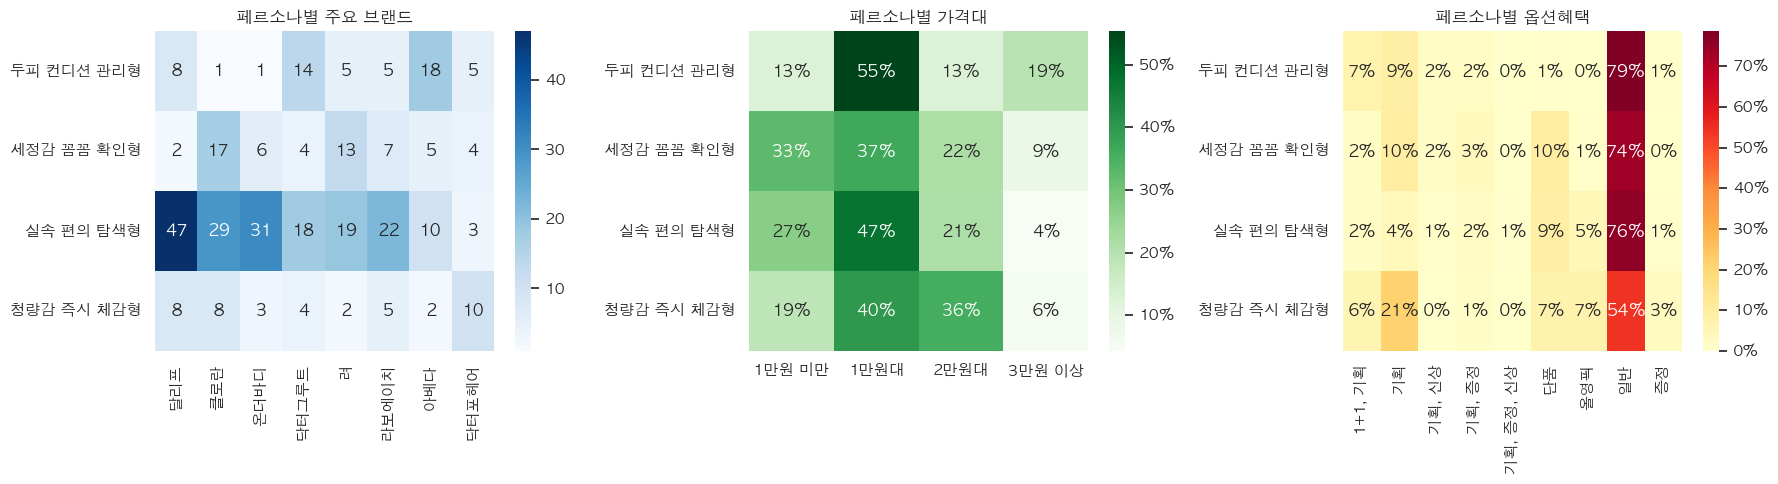

In [42]:
top_brand_cols = df["브랜드"].value_counts().head(8).index
persona_brand = pd.crosstab(df["페르소나"], df["브랜드"])[top_brand_cols]
persona_price = pd.crosstab(df["페르소나"], df["가격대"], normalize="index")
persona_option = pd.crosstab(df["페르소나"], df["옵션혜택"], normalize="index")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.heatmap(persona_brand, annot=True, fmt=".0f", cmap="Blues", ax=axes[0])
draw_percent_heatmap(persona_price, "페르소나별 가격대", "Greens", axes[1])
draw_percent_heatmap(persona_option, "페르소나별 옵션혜택", "YlOrRd", axes[2])
axes[0].set_title("페르소나별 주요 브랜드")
axes[1].set_title("페르소나별 가격대")
axes[2].set_title("페르소나별 옵션혜택")
for ax in axes:
    ax.set_xlabel("")
    ax.set_ylabel("")
plt.tight_layout()
plt.show()

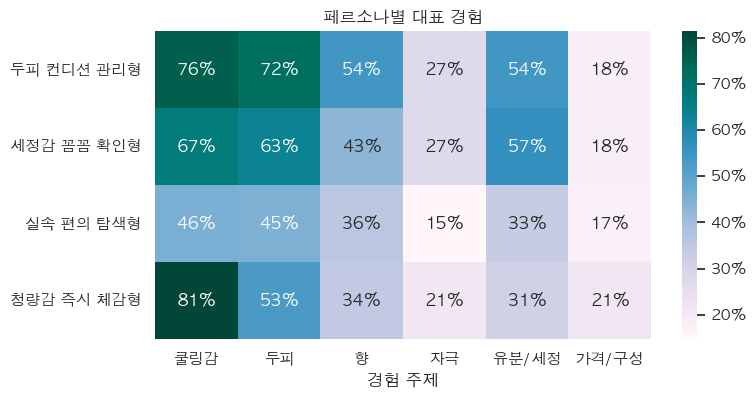

In [43]:
persona_experience = df.groupby("페르소나")[list(topic_map.values())].mean()
persona_experience.columns = topic_map.keys()

plt.figure(figsize=(8, 4))
draw_percent_heatmap(persona_experience, "페르소나별 대표 경험", "PuBuGn")
plt.xlabel("경험 주제")
plt.ylabel("")
plt.show()

#### 요약

페르소나별 선택은 하나의 상품군으로 깔끔하게 갈리기보다, 니즈에 따라 여러 상품군으로 나뉘었습니다. `실속 편의 탐색형`은 리뷰 수가 가장 많고 프리미엄 케어형·대중 세정형 모두에 반응해, 가격만 보는 소비자라기보다 편의성과 신뢰 근거를 함께 확인하는 넓은 타깃으로 볼 수 있습니다.<br><br>
상품군에서 페르소나로 이어지는 Sankey 차트는 단순 리뷰 수가 아니라 `긍정 리뷰 수` 기준으로 보았습니다. 상품군 기준 대표 흐름은 하늘색, 페르소나 기준 대표 흐름은 주황색으로 표시하고 나머지는 회색으로 낮췄습니다. 많이 언급된 조합보다 실제로 긍정 반응이 많이 나온 상품군-소비자군 조합을 보는 것이 마케팅 타깃 선정에 더 적합하기 때문입니다.<br><br>
`두피 컨디션 관리형`은 프리미엄 케어형과 대중 세정형에서 함께 반응이 나타나, 두피 진정·자극 완화·성분 근거를 먼저 제시하는 흐름으로 잡습니다. <strong>`청량감 즉시 체감형`은 기획 쿨링형과 대중 세정형의 사용 장면 중심 소재, `세정감 꼼꼼 확인형`은 유분·정수리·세정 지속감을 확인시키는 비교형 콘텐츠로 연결합니다.</strong>

## 6-3. 소비자 경험이 함께 언급되는 방식

리뷰에서는 만족과 불만이 분리되어 나타나기보다 함께 섞이는 경우가 많습니다.<br>
여기서는 만족 옆에 따라오는 불안 요소, 불만 옆에 남아 있는 기대 요소를 함께 확인합니다.

In [44]:
from collections import Counter
from itertools import combinations

basic_stopwords = {
    "있어서", "없어서", "사용하기", "사용할", "사용하", "쓰고", "않고", "나서", "이거", "요즘", "생각",
    "구매했", "후기", "분들", "다른", "한번", "정말", "너무", "살짝", "때문", "원래", "평소",
}

def get_tokens(text):
    return [w.strip() for w in str(text).split(",") if len(w.strip()) > 1 and w.strip() not in basic_stopwords]

def top_keyword_frame(data, n=15):
    words = Counter(word for text in data["키워드토큰문자열"].dropna() for word in get_tokens(text))
    return pd.DataFrame(words.most_common(n), columns=["키워드", "리뷰수"])

def keyword_pair_frame(data, n_keywords=18, n_pairs=25):
    top_words = set(top_keyword_frame(data, n_keywords)["키워드"])
    pairs = Counter()
    for text in data["키워드토큰문자열"].dropna():
        words = sorted(set(w for w in get_tokens(text) if w in top_words))
        pairs.update(combinations(words, 2))
    return pd.DataFrame([(a, b, v) for (a, b), v in pairs.most_common(n_pairs)], columns=["키워드1", "키워드2", "연결수"])

def signal_keyword_frame(data, pattern, n=12):
    words = Counter()
    for text in data["키워드토큰문자열"].dropna():
        words.update(w for w in get_tokens(text) if re.search(pattern, w))
    return pd.DataFrame(words.most_common(n), columns=["키워드", "리뷰수"])

def keyword_cross_pair_frame(data, left_words, right_words, n_pairs=25):
    left_words = set(left_words)
    right_words = set(right_words)
    pairs = Counter()
    for text in data["키워드토큰문자열"].dropna():
        words = set(get_tokens(text))
        left_hits = sorted(words & left_words)
        right_hits = sorted(words & right_words)
        for left in left_hits:
            for right in right_hits:
                if left != right:
                    pairs[(left, right)] += 1
    return pd.DataFrame([(a, b, v) for (a, b), v in pairs.most_common(n_pairs)], columns=["키워드1", "키워드2", "연결수"])

def draw_keyword_treemap(data, title, color_map):
    labels = data["키워드"] + "\\n" + data["리뷰수"].astype(str)
    plt.figure(figsize=(10, 6))
    squarify.plot(sizes=data["리뷰수"], label=labels, color=color_map, alpha=0.9, text_kwargs={"fontsize": 11, "color": "white", "weight": "bold"})
    plt.title(title)
    plt.axis("off")
    plt.show()


def draw_keyword_diverging(left_data, right_data, left_label, right_label, title, left_color, right_color):
    words = list(dict.fromkeys(left_data["키워드"].head(10).tolist() + right_data["키워드"].head(10).tolist()))
    chart_data = pd.DataFrame({"키워드": words})
    chart_data[left_label] = chart_data["키워드"].map(left_data.set_index("키워드")["리뷰수"]).fillna(0)
    chart_data[right_label] = chart_data["키워드"].map(right_data.set_index("키워드")["리뷰수"]).fillna(0)
    chart_data = chart_data.sort_values([left_label, right_label], ascending=False).head(12)

    plt.figure(figsize=(9, 6))
    plt.barh(chart_data["키워드"], -chart_data[left_label], color=left_color, label=left_label)
    plt.barh(chart_data["키워드"], chart_data[right_label], color=right_color, label=right_label)
    ax = plt.gca()
    ax.axvline(0, color="#555555", linewidth=1)
    ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{abs(int(x)):,}"))
    plt.title(title)
    plt.xlabel("리뷰 수")
    plt.ylabel("")
    plt.legend(loc="lower right")
    ax.invert_yaxis()
    plt.show()

def draw_keyword_network(pair_data, title, color):
    graph = nx.Graph()
    for _, row in pair_data.iterrows():
        graph.add_edge(row["키워드1"], row["키워드2"], weight=row["연결수"])
    pos = nx.spring_layout(graph, seed=42, k=0.8)
    sizes = [graph.degree(node) * 350 for node in graph.nodes()]
    widths = [graph[u][v]["weight"] / 3 for u, v in graph.edges()]
    plt.figure(figsize=(10, 7))
    nx.draw_networkx_edges(graph, pos, width=widths, alpha=0.25, edge_color="#777777")
    nx.draw_networkx_nodes(graph, pos, node_size=sizes, node_color=color, alpha=0.85)
    nx.draw_networkx_labels(graph, pos, font_family="AppleGothic", font_size=11)
    plt.title(title)
    plt.axis("off")
    plt.show()

def draw_keyword_network_by_group(pair_data, title, primary_words, secondary_words, primary_label, secondary_label, primary_color="#74c476", secondary_color="#fdae6b", both_color="#ffd966"):
    graph = nx.Graph()
    for _, row in pair_data.iterrows():
        graph.add_edge(row["키워드1"], row["키워드2"], weight=row["연결수"])

    primary_words = set(primary_words)
    secondary_words = set(secondary_words)
    colors = []
    for node in graph.nodes():
        if node in primary_words and node in secondary_words:
            colors.append(both_color)
        elif node in secondary_words:
            colors.append(secondary_color)
        else:
            colors.append(primary_color)

    pos = nx.spring_layout(graph, seed=42, k=0.8)
    sizes = [graph.degree(node) * 350 for node in graph.nodes()]
    widths = [graph[u][v]["weight"] / 3 for u, v in graph.edges()]

    plt.figure(figsize=(10, 7))
    nx.draw_networkx_edges(graph, pos, width=widths, alpha=0.25, edge_color="#777777")
    nx.draw_networkx_nodes(graph, pos, node_size=sizes, node_color=colors, alpha=0.9)
    nx.draw_networkx_labels(graph, pos, font_family="AppleGothic", font_size=11)

    legend_handles = [
        plt.Line2D([0], [0], marker="o", color="w", label=primary_label, markerfacecolor=primary_color, markersize=11),
        plt.Line2D([0], [0], marker="o", color="w", label=secondary_label, markerfacecolor=secondary_color, markersize=11),
        plt.Line2D([0], [0], marker="o", color="w", label="둘 다 등장", markerfacecolor=both_color, markersize=11),
    ]
    plt.legend(handles=legend_handles, loc="lower left", frameon=True)
    plt.title(title)
    plt.axis("off")
    plt.show()


def draw_pair_bubble(pair_data, title, color):
    plot_data = pair_data.head(15).copy()
    plot_data["키워드 연결"] = plot_data["키워드1"] + " + " + plot_data["키워드2"]
    plt.figure(figsize=(9, 6))
    sns.scatterplot(data=plot_data, x="연결수", y="키워드 연결", size="연결수", sizes=(80, 900), color=color, legend=False)
    plt.title(title)
    plt.xlabel("함께 언급된 리뷰 수")
    plt.ylabel("")
    plt.grid(axis="x", alpha=0.25)
    plt.show()

### 만족 경험은 어떤 불안 요소와 함께 나타나는가

#### 만족 경험에 따라온 불안 요소

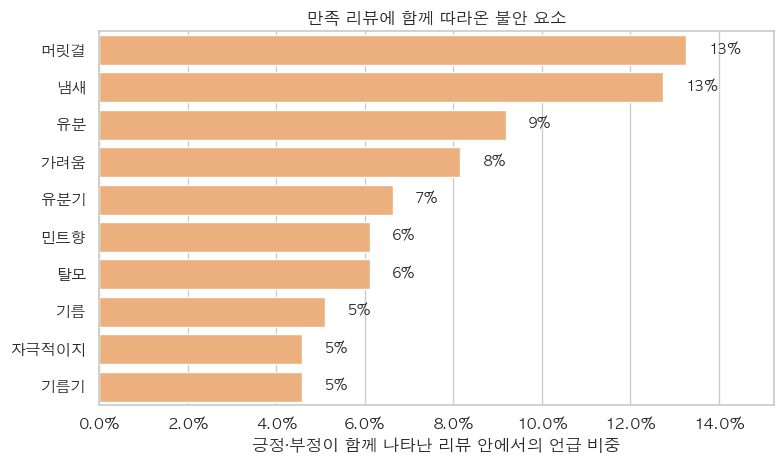

In [45]:
positive_reviews = df[df["긍정신호여부"] == 1]
mixed_reviews = df[(df["긍정신호여부"] == 1) & (df["부정신호여부"] == 1)]

satisfaction_pattern = r"시원|개운|상쾌|세정|거품|좋|만족|쿨링|여름|부드|재구매"
anxiety_pattern = r"자극|건조|향|냄새|지속|약|부족|가려|기름|유분|머릿결|탈모"
positive_keywords = signal_keyword_frame(positive_reviews, satisfaction_pattern, 15)
anxiety_keywords = signal_keyword_frame(mixed_reviews, anxiety_pattern, 15)

anxiety_focus = anxiety_keywords.head(10).copy()
anxiety_focus["언급 비중"] = anxiety_focus["리뷰수"] / len(mixed_reviews)

plt.figure(figsize=(8, 4.8))
sns.barplot(data=anxiety_focus, x="언급 비중", y="키워드", color="#fdae6b")
plt.title("만족 리뷰에 함께 따라온 불안 요소")
plt.xlabel("긍정·부정이 함께 나타난 리뷰 안에서의 언급 비중")
plt.ylabel("")
set_percent_axis(plt.gca(), "x")
plt.xlim(0, anxiety_focus["언급 비중"].max() * 1.15)

for i, row in anxiety_focus.iterrows():
    plt.text(row["언급 비중"] + 0.005, i, f'{row["언급 비중"]:.0%}', va="center", fontsize=10)

plt.tight_layout()
plt.show()

#### 만족 경험과 불안 요소의 연결 구조

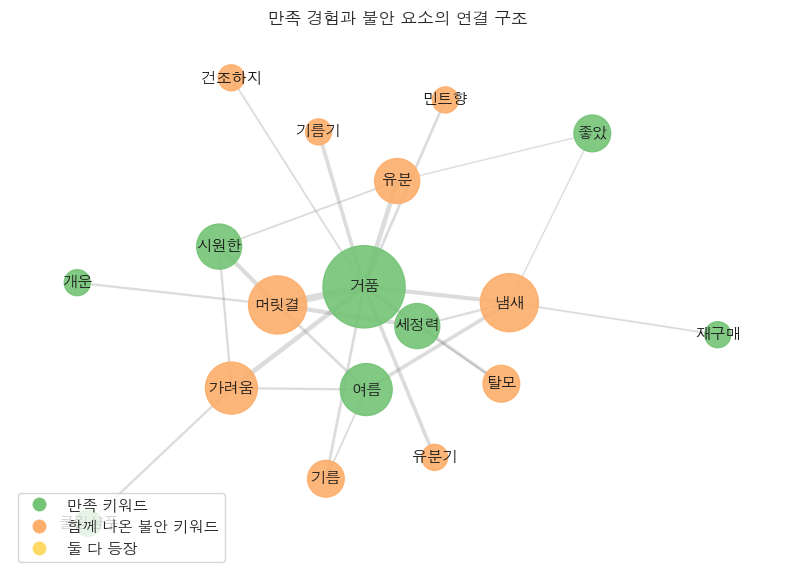

In [46]:
positive_pairs = keyword_cross_pair_frame(
    mixed_reviews,
    positive_keywords["키워드"].head(12),
    anxiety_keywords["키워드"].head(12),
)
draw_keyword_network_by_group(
    positive_pairs,
    "만족 경험과 불안 요소의 연결 구조",
    positive_keywords["키워드"].head(12),
    anxiety_keywords["키워드"].head(12),
    "만족 키워드",
    "함께 나온 불안 키워드",
)

#### 요약

만족 리뷰에서는 `거품`, `세정력`, `시원한`, `여름` 같은 즉시 체감형 키워드가 크게 나타났고, 동시에 불안 키워드도 함께 따라왔습니다.<br><br>
<strong>광고에서는 `시원하고 잘 씻긴다`를 빠르게 보여주고, 상세페이지에서는 향·자극·지속감처럼 망설임을 만들 수 있는 요소를 먼저 설명하는 구성이 필요합니다.</strong>

### 불만 경험은 어떤 기대 요소와 함께 나타나는가

#### 불만 경험에 남은 기대 요소

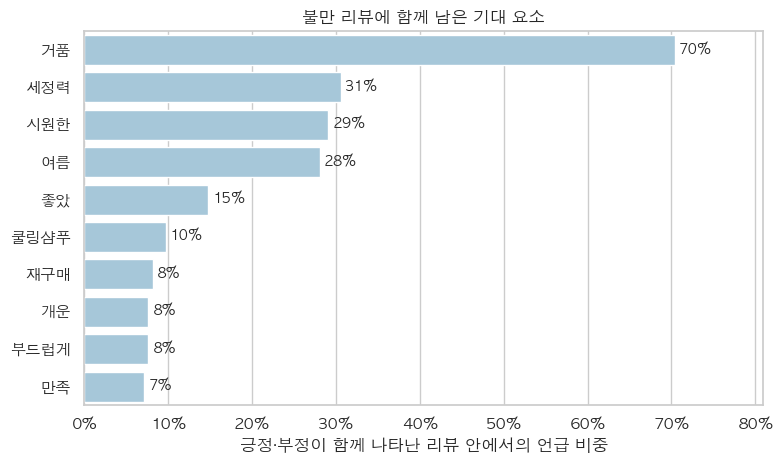

In [47]:
negative_reviews = df[df["부정신호여부"] == 1]
complaint_pattern = r"자극|건조|향|냄새|지속|약|부족|가려|기름|유분|머릿결|탈모"
expectation_pattern = r"시원|개운|상쾌|세정|거품|좋|만족|쿨링|여름|부드|재구매"
negative_keywords = signal_keyword_frame(negative_reviews, complaint_pattern, 15)
expectation_keywords = signal_keyword_frame(mixed_reviews, expectation_pattern, 15)

expectation_focus = expectation_keywords.head(10).copy()
expectation_focus["언급 비중"] = expectation_focus["리뷰수"] / len(mixed_reviews)

plt.figure(figsize=(8, 4.8))
sns.barplot(data=expectation_focus, x="언급 비중", y="키워드", color="#9ecae1")
plt.title("불만 리뷰에 함께 남은 기대 요소")
plt.xlabel("긍정·부정이 함께 나타난 리뷰 안에서의 언급 비중")
plt.ylabel("")
set_percent_axis(plt.gca(), "x")
plt.xlim(0, expectation_focus["언급 비중"].max() * 1.15)

for i, row in expectation_focus.iterrows():
    plt.text(row["언급 비중"] + 0.005, i, f'{row["언급 비중"]:.0%}', va="center", fontsize=10)

plt.tight_layout()
plt.show()

#### 불만 경험과 기대 요소의 연결 구조

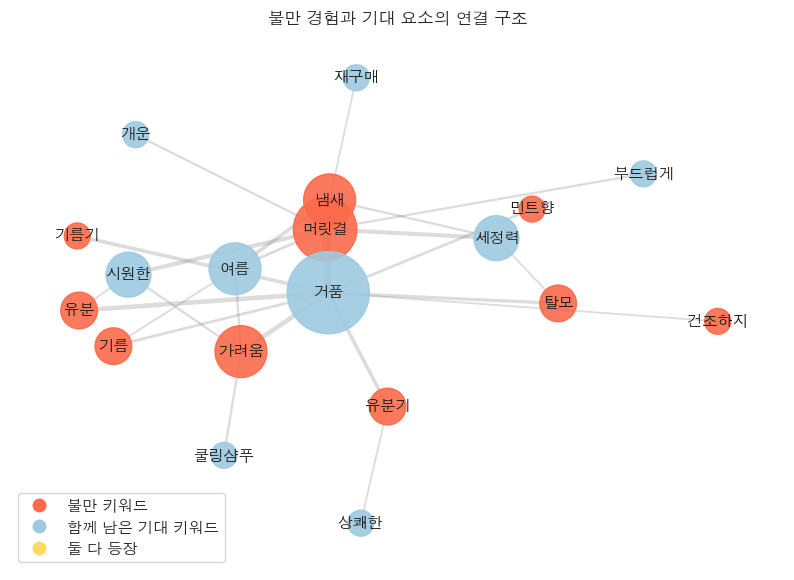

In [48]:
negative_pairs = keyword_cross_pair_frame(
    mixed_reviews,
    negative_keywords["키워드"].head(12),
    expectation_keywords["키워드"].head(12),
)
draw_keyword_network_by_group(
    negative_pairs,
    "불만 경험과 기대 요소의 연결 구조",
    negative_keywords["키워드"].head(12),
    expectation_keywords["키워드"].head(12),
    "불만 키워드",
    "함께 남은 기대 키워드",
    "#fb6a4a",
    "#9ecae1",
)

#### 요약

불만 리뷰에서도 `거품`, `세정력`, `시원한` 같은 기대 키워드가 함께 남아 있었습니다. 소비자가 제품을 완전히 부정한다기보다, 기대한 사용감과 실제 체감 사이의 차이를 말하고 있습니다.<br><br>
<strong>마케팅에서는 장점을 버리기보다 기대 수준을 정확히 조정해야 합니다.</strong> 강한 쿨링을 기대하는 소비자에게는 지속 시간과 체감 강도를 명확히 보여주고, 세정력 기대가 큰 소비자에게는 유분·정수리·두피 사용 장면을 구체적으로 제시합니다.

### 상품 메시지와 실제 소비자 경험은 어떻게 연결되는가

#### 상품 메시지와 만족/불만 경험

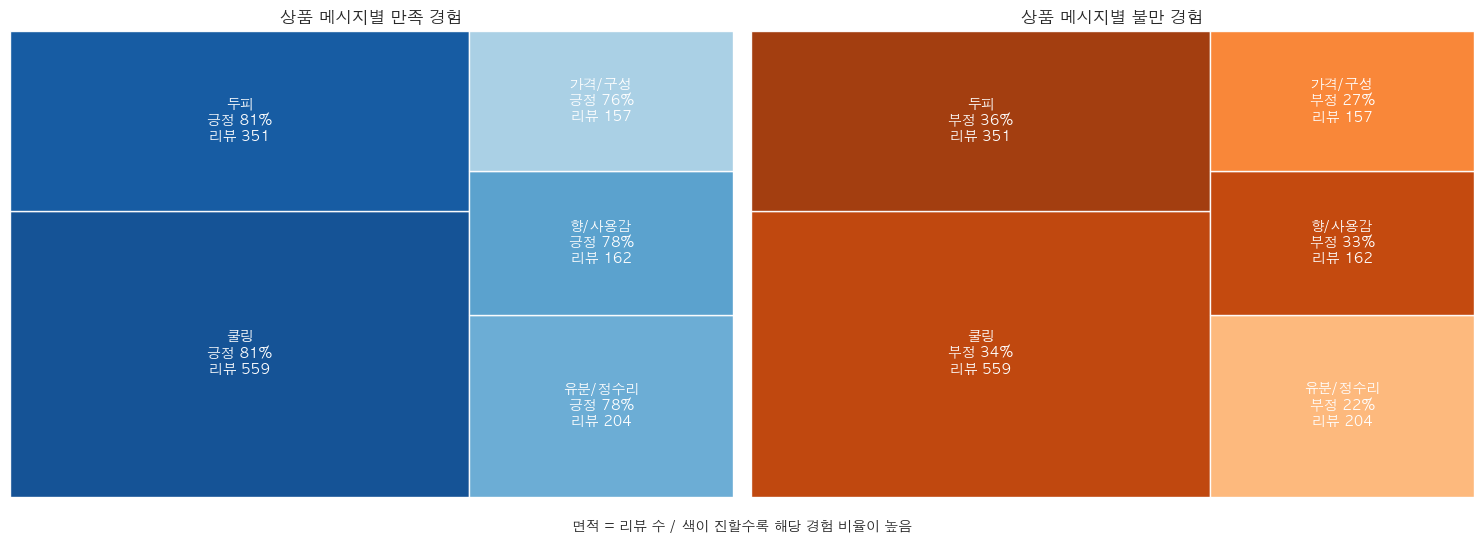

In [49]:
message_positive_rows = []
message_negative_rows = []
for label in message_patterns:
    target = df[message_flags[label] == 1]
    message_positive_rows.append({"상품 메시지": label, "긍정비율": target["긍정신호여부"].mean(), "리뷰수": len(target)})
    message_negative_rows.append({"상품 메시지": label, "부정비율": target["부정신호여부"].mean(), "리뷰수": len(target)})

message_positive = pd.DataFrame(message_positive_rows).sort_values("리뷰수", ascending=False)
message_negative = pd.DataFrame(message_negative_rows).sort_values("리뷰수", ascending=False)

positive_score = (message_positive["긍정비율"] - message_positive["긍정비율"].min()) / (message_positive["긍정비율"].max() - message_positive["긍정비율"].min())
negative_score = (message_negative["부정비율"] - message_negative["부정비율"].min()) / (message_negative["부정비율"].max() - message_negative["부정비율"].min())
positive_colors = plt.cm.Blues(0.35 + positive_score.fillna(0) * 0.55)
negative_colors = plt.cm.Oranges(0.35 + negative_score.fillna(0) * 0.55)
positive_labels = message_positive.apply(lambda x: f"{x['상품 메시지']}\n긍정 {x['긍정비율']:.0%}\n리뷰 {x['리뷰수']}", axis=1)
negative_labels = message_negative.apply(lambda x: f"{x['상품 메시지']}\n부정 {x['부정비율']:.0%}\n리뷰 {x['리뷰수']}", axis=1)

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
squarify.plot(sizes=message_positive["리뷰수"], label=positive_labels, color=positive_colors, alpha=0.95, text_kwargs={"fontsize": 10, "color": "white", "weight": "bold"}, ax=axes[0])
squarify.plot(sizes=message_negative["리뷰수"], label=negative_labels, color=negative_colors, alpha=0.95, text_kwargs={"fontsize": 10, "color": "white", "weight": "bold"}, ax=axes[1])
axes[0].set_title("상품 메시지별 만족 경험")
axes[1].set_title("상품 메시지별 불만 경험")
for ax in axes:
    ax.axis("off")
fig.text(0.5, 0.02, "면적 = 리뷰 수 / 색이 진할수록 해당 경험 비율이 높음", ha="center", fontsize=10)
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()

#### 상품군별 경험 차이

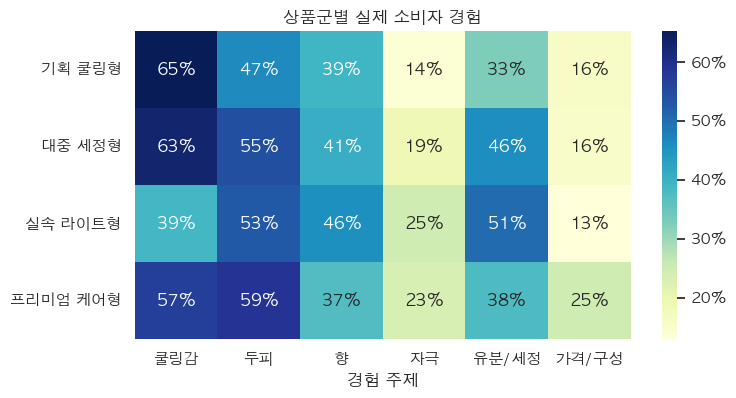

In [50]:
experience_cols = list(topic_map.values())
productgroup_experience = df.groupby("상품군")[experience_cols].mean()
productgroup_experience.columns = topic_map.keys()

plt.figure(figsize=(8, 4))
draw_percent_heatmap(productgroup_experience, "상품군별 실제 소비자 경험", "YlGnBu")
plt.xlabel("경험 주제")
plt.ylabel("")
plt.show()

#### 브랜드별 경험 차이

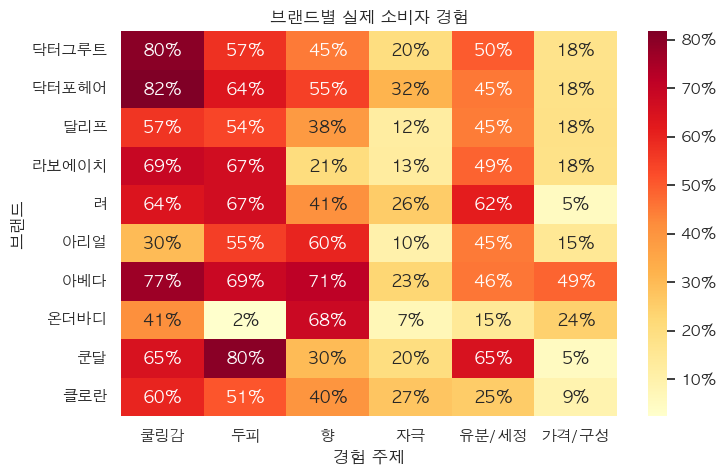

In [51]:
top_brands = df["브랜드"].value_counts().head(10).index
brand_experience = df[df["브랜드"].isin(top_brands)].groupby("브랜드")[experience_cols].mean()
brand_experience.columns = topic_map.keys()

plt.figure(figsize=(8, 5))
draw_percent_heatmap(brand_experience, "브랜드별 실제 소비자 경험", "YlOrRd")
plt.xlabel("경험 주제")
plt.ylabel("브랜드")
plt.show()

#### 가격대별 경험 차이

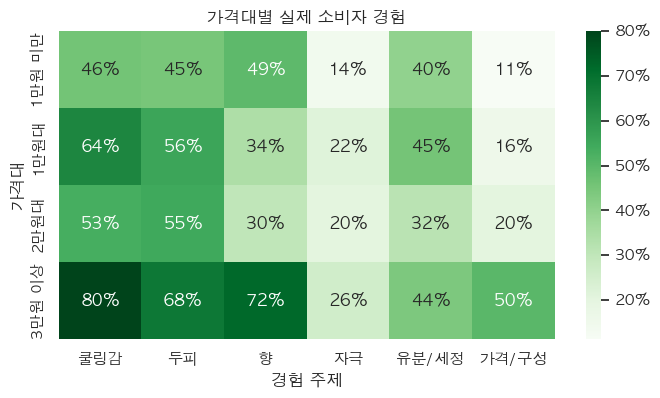

In [52]:
price_experience = df.groupby("가격대")[experience_cols].mean()
price_experience.columns = topic_map.keys()

plt.figure(figsize=(8, 4))
draw_percent_heatmap(price_experience, "가격대별 실제 소비자 경험", "Greens")
plt.xlabel("경험 주제")
plt.ylabel("가격대")
plt.show()

#### 페르소나별 경험 차이

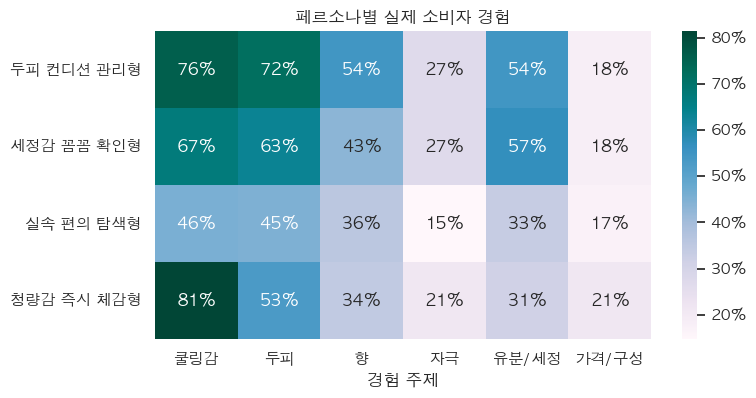

In [53]:
persona_experience = df.groupby("페르소나")[experience_cols].mean()
persona_experience.columns = topic_map.keys()

plt.figure(figsize=(8, 4))
draw_percent_heatmap(persona_experience, "페르소나별 실제 소비자 경험", "PuBuGn")
plt.xlabel("경험 주제")
plt.ylabel("")
plt.show()

#### 요약

상품 메시지는 실제 리뷰 경험과 맞을 때 광고 카피로 확장하기 쉽고, 기대와 실제 경험이 어긋나는 지점은 구매 전 이탈을 만드는 리스크입니다.<br><br>
이번 결과에서는 상품군·브랜드·가격대·페르소나에 따라 함께 언급되는 경험 조합이 달라졌습니다. <strong>하나의 대표 카피로 전체를 밀기보다, 상품군별 핵심 경험과 페르소나별 불안 요소를 같이 묶은 메시지 조합이 더 적합합니다.</strong> 예를 들어 쿨링 상품은 `즉각 시원함`과 `자극 부담 완화`를, 두피 케어 상품은 `세정력`과 `두피 진정 근거`를 같이 제시합니다.

## 7-2. 마케팅 인사이트

앞선 분석 결과를 시장 구조, 소비자 경험, 브랜드/가격/옵션 전략, 신제품 컨셉 방향으로 정리합니다.<br><br>
<strong>이 섹션은 추가 분석보다 실행 방향을 정리하는 파트입니다.</strong>

### 시장 구조 인사이트

#### 경쟁 브랜드

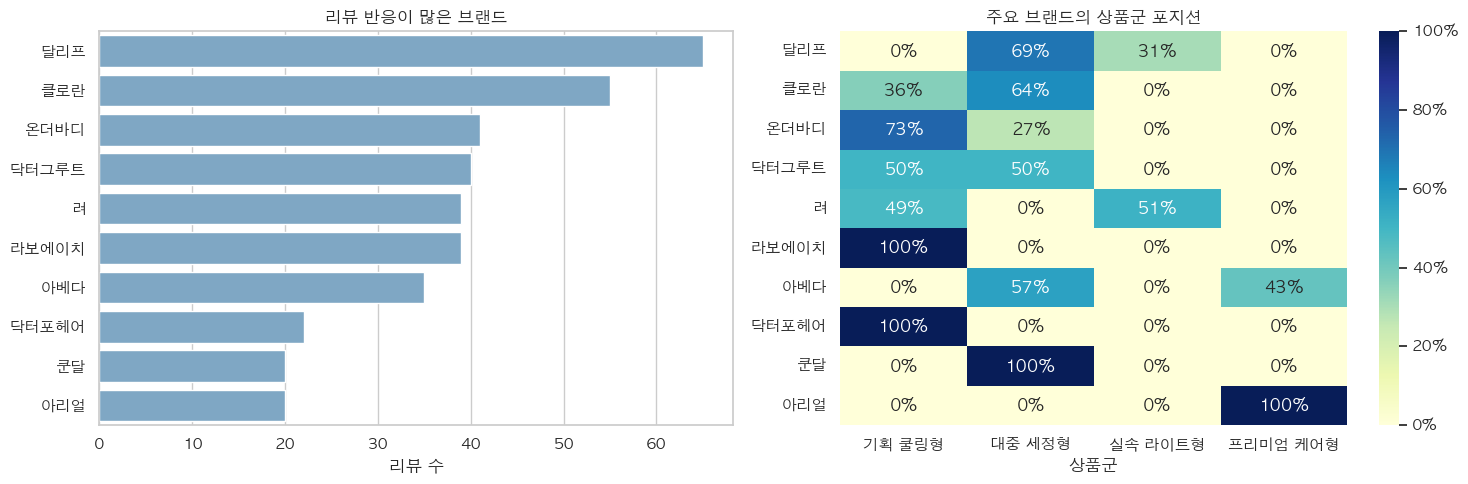

In [54]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
top_brand_review = df["브랜드"].value_counts().head(10).reset_index()
top_brand_review.columns = ["브랜드", "리뷰수"]
brand_group_share = pd.crosstab(df["브랜드"], df["상품군"], normalize="index").loc[top_brand_review["브랜드"]]

sns.barplot(data=top_brand_review, y="브랜드", x="리뷰수", ax=axes[0], color="#74a9cf")
draw_percent_heatmap(brand_group_share, "주요 브랜드의 상품군 포지션", "YlGnBu", axes[1])
axes[0].set_title("리뷰 반응이 많은 브랜드")
axes[0].set_xlabel("리뷰 수")
axes[0].set_ylabel("")
axes[1].set_xlabel("상품군")
axes[1].set_ylabel("")
plt.tight_layout()
plt.show()

#### 가격 포지셔닝

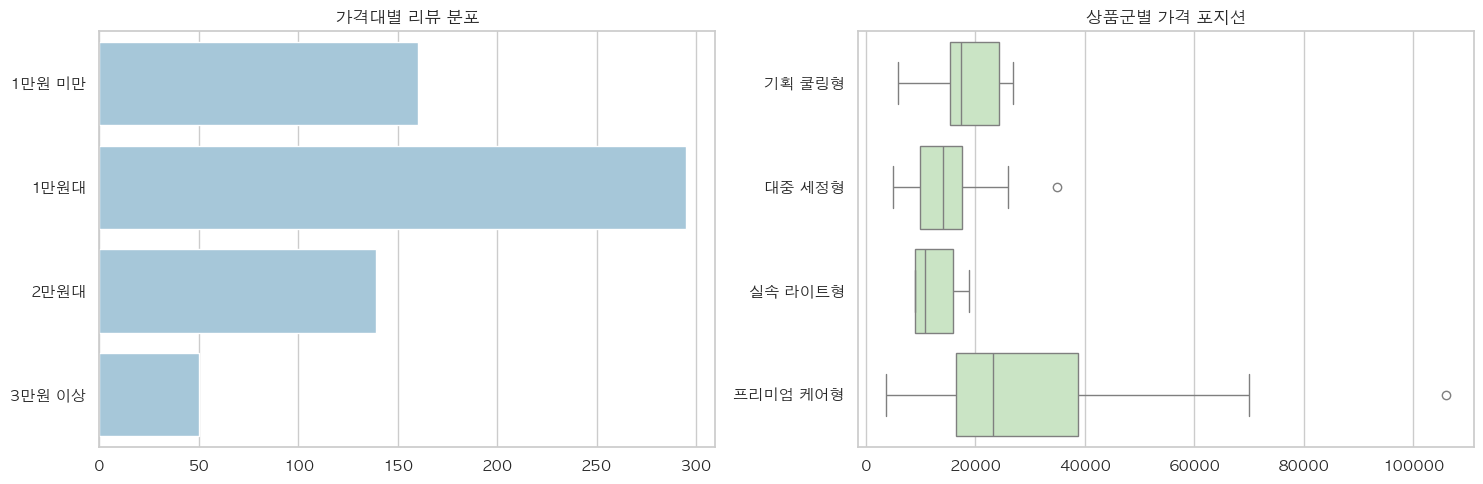

In [55]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
price_order = ["1만원 미만", "1만원대", "2만원대", "3만원 이상"]

sns.countplot(data=df, y="가격대", order=price_order, ax=axes[0], color="#9ecae1")
sns.boxplot(data=product_features, y="상품군", x="가격", ax=axes[1], color="#c7e9c0")

axes[0].set_title("가격대별 리뷰 분포")
axes[1].set_title("상품군별 가격 포지션")
for ax in axes:
    ax.set_xlabel("")
    ax.set_ylabel("")

plt.tight_layout()
plt.show()

#### 시장 공백

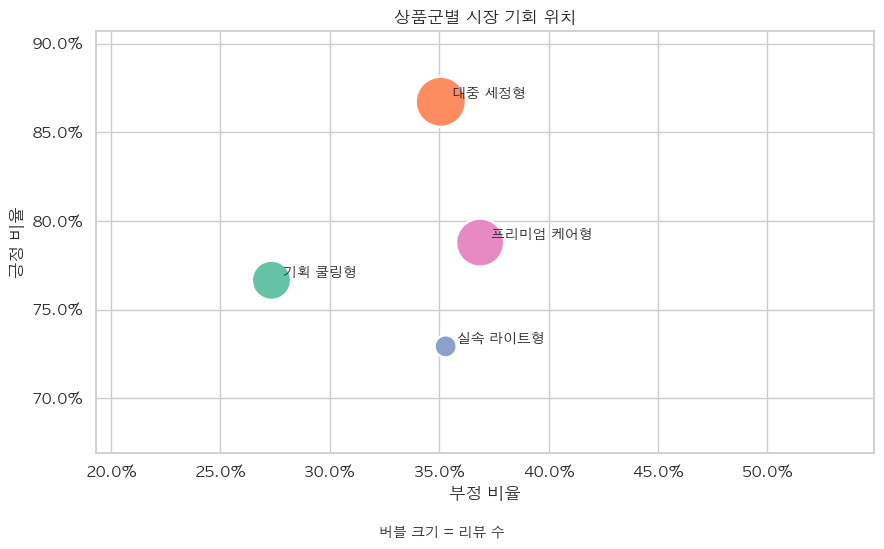

In [56]:
market_gap = df.groupby("상품군", as_index=False).agg(
    리뷰수=("리뷰내용", "count"), 긍정비율=("긍정신호여부", "mean"), 부정비율=("부정신호여부", "mean")
)
market_gap["기회점수"] = market_gap["긍정비율"] - market_gap["부정비율"]

plt.figure(figsize=(9, 5.5))
ax = sns.scatterplot(data=market_gap, x="부정비율", y="긍정비율", size="리뷰수", hue="상품군", sizes=(250, 1300), palette="Set2", legend=False)
for _, row in market_gap.iterrows():
    ax.annotate(row["상품군"], (row["부정비율"], row["긍정비율"]), xytext=(8, 3), textcoords="offset points", fontsize=10)
plt.title("상품군별 시장 기회 위치")
plt.xlabel("부정 비율")
plt.ylabel("긍정 비율")
set_percent_axis(ax, "both")
plt.xlim(max(0, market_gap["부정비율"].min() - 0.08), min(1, market_gap["부정비율"].max() + 0.18))
plt.ylim(max(0, market_gap["긍정비율"].min() - 0.06), min(1.02, market_gap["긍정비율"].max() + 0.04))
plt.figtext(0.5, 0.01, "버블 크기 = 리뷰 수", ha="center", fontsize=10)
plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.show()

#### 요약

리뷰 반응은 일부 상위 브랜드에 집중되어 있고, 시장의 중심 가격대는 1만원대입니다. 동시에 상품군별로 가격과 소비자 반응이 다르게 나뉘었습니다.<br><br>
<strong>기회는 단순히 더 저렴한 상품이 아니라, 대중형 가격대에서 쿨링·두피 케어 경험을 명확히 주면서 불안 요소를 줄이는 포지션에 있습니다.</strong> 프리미엄 상품은 가격 설득 근거가 더 필요하고, 실속형 상품은 편의성과 구성 혜택을 더 분명히 보여주는 전략으로 정리됩니다.

### 소비자 경험 인사이트

#### 핵심 만족/불만 경험

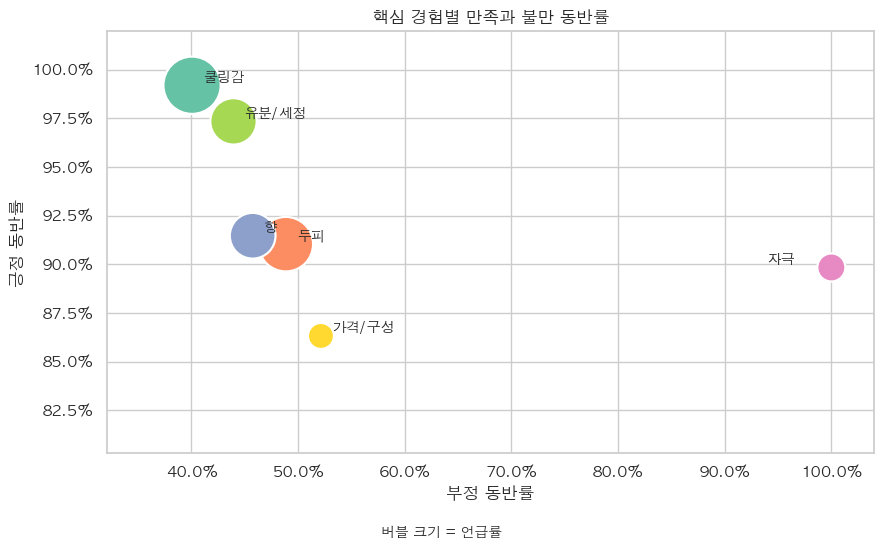

In [57]:
experience_summary = pd.DataFrame({
    "경험": topic_map.keys(),
    "언급률": [df[col].mean() for col in topic_map.values()],
    "긍정동반률": [df.loc[df[col] == 1, "긍정신호여부"].mean() for col in topic_map.values()],
    "부정동반률": [df.loc[df[col] == 1, "부정신호여부"].mean() for col in topic_map.values()],
})

plt.figure(figsize=(9, 5.5))
ax = sns.scatterplot(data=experience_summary, x="부정동반률", y="긍정동반률", size="언급률", hue="경험", sizes=(350, 1700), palette="Set2", legend=False)
for _, row in experience_summary.iterrows():
    offset = (-46, 3) if row["부정동반률"] > 0.9 else (8, 3)
    ax.annotate(row["경험"], (row["부정동반률"], row["긍정동반률"]), xytext=offset, textcoords="offset points", fontsize=10)
plt.title("핵심 경험별 만족과 불만 동반률")
plt.xlabel("부정 동반률")
plt.ylabel("긍정 동반률")
set_percent_axis(ax, "both")
plt.xlim(max(0, experience_summary["부정동반률"].min() - 0.08), min(1.04, experience_summary["부정동반률"].max() + 0.06))
plt.ylim(max(0, experience_summary["긍정동반률"].min() - 0.06), min(1.02, experience_summary["긍정동반률"].max() + 0.04))
ax.xaxis.set_major_locator(mtick.MultipleLocator(0.1))
plt.figtext(0.5, 0.01, "버블 크기 = 언급률", ha="center", fontsize=10)
plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.show()

#### 구매 전 해소가 필요한 불만 경험

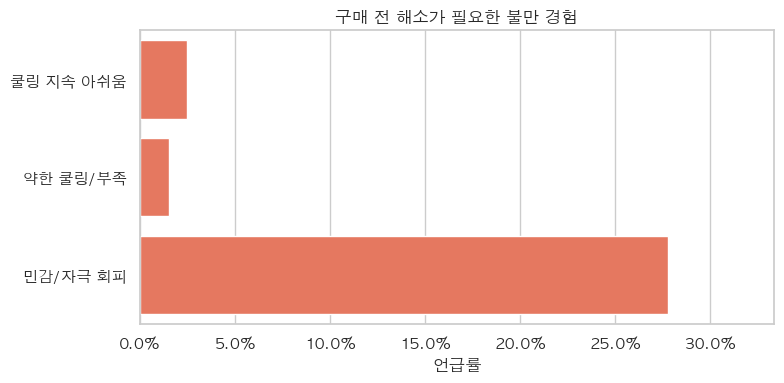

In [58]:
pain_cols = {
    "쿨링 지속 아쉬움": "쿨링지속아쉬움여부",
    "약한 쿨링/부족": "약한쿨링부족여부",
    "민감/자극 회피": "민감자극회피여부",
}
pain_summary = pd.DataFrame({"불만 경험": pain_cols.keys(), "언급률": [df[col].mean() for col in pain_cols.values()]})

plt.figure(figsize=(8, 4))
sns.barplot(data=pain_summary, y="불만 경험", x="언급률", color="#fb6a4a")
plt.title("구매 전 해소가 필요한 불만 경험")
plt.xlabel("언급률")
plt.ylabel("")
set_percent_axis(plt.gca(), "x")
plt.xlim(0, pain_summary["언급률"].max() * 1.2)
plt.tight_layout()
plt.show()

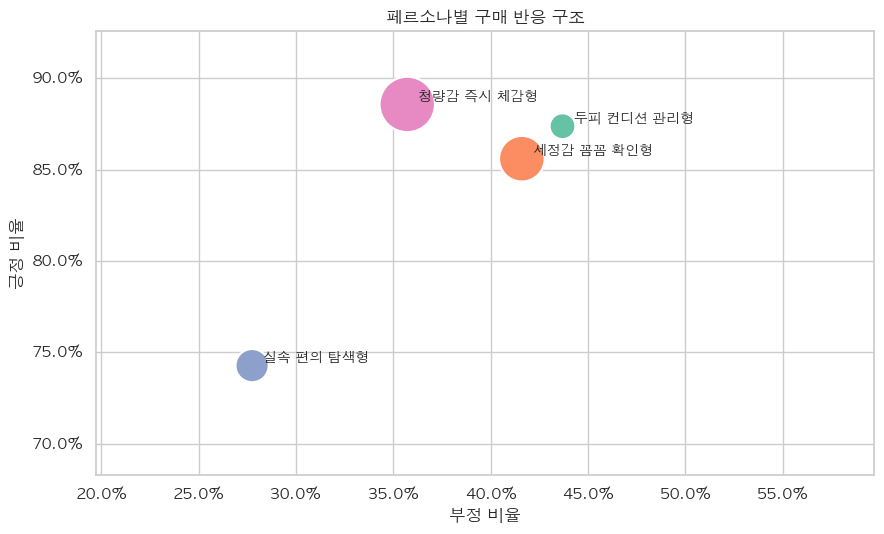

In [59]:
purchase_factors = df.groupby("페르소나", as_index=False).agg(
    평균평점=("리뷰평점", "mean"), 도움반응=("도움돼요점수", "mean"), 긍정비율=("긍정신호여부", "mean"), 부정비율=("부정신호여부", "mean")
)

plt.figure(figsize=(9, 5.5))
ax = sns.scatterplot(data=purchase_factors, x="부정비율", y="긍정비율", size="도움반응", hue="페르소나", sizes=(350, 1600), palette="Set2", legend=False)
for _, row in purchase_factors.iterrows():
    ax.annotate(row["페르소나"], (row["부정비율"], row["긍정비율"]), xytext=(8, 3), textcoords="offset points", fontsize=10)
plt.title("페르소나별 구매 반응 구조")
plt.xlabel("부정 비율")
plt.ylabel("긍정 비율")
set_percent_axis(ax, "both")
plt.xlim(max(0, purchase_factors["부정비율"].min() - 0.08), min(1, purchase_factors["부정비율"].max() + 0.16))
plt.ylim(max(0, purchase_factors["긍정비율"].min() - 0.06), min(1.02, purchase_factors["긍정비율"].max() + 0.04))
plt.tight_layout()
plt.show()

#### 소비자 유형별 특징

In [60]:
persona_strategy = pd.DataFrame([
    ["실속 편의 탐색형", "편의성·신뢰 근거·구성 확인", "프리미엄 케어형/대중 세정형", "가격만 앞세우기보다 사용 편의와 구매 명분을 함께 제시"],
    ["두피 컨디션 관리형", "두피 진정·자극 완화", "프리미엄 케어형/대중 세정형", "성분 근거와 민감 두피 안심 메시지"],
    ["청량감 즉시 체감형", "빠른 쿨링 체감", "기획 쿨링형/대중 세정형", "사용 직후 시원함을 시각적으로 제시"],
    ["세정감 꼼꼼 확인형", "유분·정수리·세정 지속감", "프리미엄 케어형/대중 세정형", "전후 비교와 지속감 근거 제시"],
], columns=["페르소나", "핵심 니즈", "반응 상품군", "메시지 방향"])
persona_strategy

,페르소나,핵심 니즈,반응 상품군,메시지 방향
0,실속 편의 탐색형,편의성·신뢰 근거·구성 확인,프리미엄 케어형/대중 세정형,가격만 앞세우기보다 사용 편의와 구매 명분을 함께 제시
1,두피 컨디션 관리형,두피 진정·자극 완화,프리미엄 케어형/대중 세정형,성분 근거와 민감 두피 안심 메시지
2,청량감 즉시 체감형,빠른 쿨링 체감,기획 쿨링형/대중 세정형,사용 직후 시원함을 시각적으로 제시
3,세정감 꼼꼼 확인형,유분·정수리·세정 지속감,프리미엄 케어형/대중 세정형,전후 비교와 지속감 근거 제시


#### 요약

핵심 만족 경험은 쿨링감과 두피 컨디션에서 크게 나타났고, 구매 전 불안은 민감·자극 회피에서 가장 크게 나타났습니다. 지속감과 강도 아쉬움은 규모는 작지만, 기대 수준을 조정해야 하는 보조 리스크로 확인했습니다.<br><br>
<strong>마케팅 메시지는 쿨링 체감을 전면에 두되, 구매 전 불안을 낮추는 근거를 함께 제공해야 합니다.</strong> 페르소나별로 가격·구성, 두피 진정, 즉각 쿨링, 세정 지속감의 우선순위를 다르게 가져가는 전략이 필요합니다.

### 브랜드/가격/옵션 전략 인사이트

In [61]:
strategy_table = pd.DataFrame([
    ["브랜드", "대표 상품군과 페르소나를 분리해 운영", "브랜드별로 리뷰가 몰리는 상품군이 달라 하나의 카피로 묶기 어렵다"],
    ["가격", "1만원대는 대중 확장, 고가는 근거 강화", "1만원대가 가장 넓은 반응을 만들고 고가는 기대 불일치 리스크가 커진다"],
    ["옵션", "기획·증정은 구매 명분, 1+1은 가격 저항 완화", "혜택은 좋지만 단순 할인보다 지금 살 이유를 같이 제시해야 한다"],
    ["상품 메시지", "쿨링 체감 + 불안 해소를 세트로 구성", "만족 키워드 옆에 자극·향·지속감 불안이 같이 따라온다"],
], columns=["전략 축", "실행 방향", "근거"])
strategy_table

,전략 축,실행 방향,근거
0,브랜드,대표 상품군과 페르소나를 분리해 운영,브랜드별로 리뷰가 몰리는 상품군이 달라 하나의 카피로 묶기 어렵다
1,가격,"1만원대는 대중 확장, 고가는 근거 강화",1만원대가 가장 넓은 반응을 만들고 고가는 기대 불일치 리스크가 커진다
2,옵션,"기획·증정은 구매 명분, 1+1은 가격 저항 완화",혜택은 좋지만 단순 할인보다 지금 살 이유를 같이 제시해야 한다
3,상품 메시지,쿨링 체감 + 불안 해소를 세트로 구성,만족 키워드 옆에 자극·향·지속감 불안이 같이 따라온다


#### 요약

브랜드, 가격, 옵션, 상품 메시지는 따로 움직이기보다 하나의 구매 설득 구조로 연결되어야 합니다.<br><br>
<strong>가장 적합한 방향은 `상품군별 대표 경험`과 `페르소나별 불안 요소`를 같이 묶어 메시지를 설계하는 것입니다.</strong> 같은 쿨링 샴푸라도 실속형에는 구성과 편의성을, 두피 케어형에는 진정 근거와 자극 완화를 우선 제시하는 식으로 운영해야 합니다.

### 신제품 컨셉 방향

In [62]:
concept_table = pd.DataFrame([
    ["1차 타깃", "두피 컨디션 관리형", "두피·자극 불안을 확인하면서도 프리미엄 케어형과 대중 세정형 모두에서 반응이 있는 소비자", "두피는 편안하게, 정수리는 시원하게"],
    ["확장 타깃", "청량감 즉시 체감형", "기획 쿨링형과 대중 세정형에서 긍정 반응이 확인되어 광고 훅을 만들기 쉬운 소비자", "샴푸하는 순간 느껴지는 즉각 쿨링"],
    ["보조 타깃", "세정감 꼼꼼 확인형", "유분·정수리·세정 표현에 반응하지만 기능 근거를 함께 확인하는 소비자", "기름진 정수리까지 개운하게"],
    ["낮은 우선순위", "실속 편의 탐색형", "리뷰 규모는 크지만 니즈가 넓게 분산되어 1차 기능 컨셉보다 보조 메시지로 활용하기 적합한 소비자", "가격 혜택과 구성 중심 보조 메시지"],
], columns=["우선순위", "소비자군", "선정 이유", "메시지 방향"])
concept_table

,우선순위,소비자군,선정 이유,메시지 방향
0,1차 타깃,두피 컨디션 관리형,두피·자극 불안을 확인하면서도 프리미엄 케어형과 대중 세정형 모두에서 반응이 있는 소비자,"두피는 편안하게, 정수리는 시원하게"
1,확장 타깃,청량감 즉시 체감형,기획 쿨링형과 대중 세정형에서 긍정 반응이 확인되어 광고 훅을 만들기 쉬운 소비자,샴푸하는 순간 느껴지는 즉각 쿨링
2,보조 타깃,세정감 꼼꼼 확인형,유분·정수리·세정 표현에 반응하지만 기능 근거를 함께 확인하는 소비자,기름진 정수리까지 개운하게
3,낮은 우선순위,실속 편의 탐색형,리뷰 규모는 크지만 니즈가 넓게 분산되어 1차 기능 컨셉보다 보조 메시지로 활용하기 적합한 소비자,가격 혜택과 구성 중심 보조 메시지


#### 요약

먼저 공략할 소비자군은 `두피 컨디션 관리형`입니다. 이 그룹은 단순히 시원한 샴푸보다, 두피가 불편하지 않은 쿨링 제품을 찾는 흐름이 더 뚜렷했습니다.<br><br>

- 1차 타깃: `두피 컨디션 관리형`
  - 근거: 쿨링감과 함께 두피, 자극, 진정 표현이 같이 나타남
  - 메시지: `강한 쿨링`보다 `편안한 쿨링` 중심
  - 상세페이지 방향: 즉각 쿨링 → 유분·정수리 케어 → 자극 부담 완화 순서로 설득

- 확장 타깃: `청량감 즉시 체감형`
  - 근거: 기획 쿨링형과 대중 세정형에서 긍정 반응이 확인되어, 광고 초반에 직관적인 체감 메시지로 관심을 만들기 쉬움
  - 메시지: `샴푸하는 순간 느껴지는 시원함`처럼 사용 직후 체감 문구
  - 전환 방향: 클릭 이후에는 `두피까지 편안한 쿨링`으로 메시지를 좁혀 차별화

- 보조 메시지: `실속 편의 탐색형`
  - 근거: 리뷰 규모는 가장 크지만, 기능 문제 해결 니즈가 넓게 분산되어 1차 컨셉 타깃보다는 구매 명분을 보강하는 역할에 적합
  - 메시지: 가격 혜택, 구성, 사용 편의성 중심

<strong>최종 방향은 `두피 컨디션 관리형`을 1차 타깃으로 잡고, `청량감 즉시 체감형`을 광고 확장 타깃으로 가져가는 것입니다.</strong> 핵심 메시지는 `두피는 편안하게, 정수리는 시원하게`로 정리할 수 있습니다.

## 다음 단계

05 노트북에서는 상품 데이터와 리뷰 텍스트 분석 결과를 연결해 `누구에게 어떤 메시지로 접근할지`를 정리했습니다.<br><br>

포트폴리오 웹사이트에서는 이 결과를 바탕으로 브랜드와 콘텐츠 제작 방향까지 확장합니다.

- 브랜드 설계: 어떤 브랜드 톤과 포지션으로 시장에 들어갈지 정리
- 대표 상품 컨셉: 어떤 소비자군을 타깃으로, 어떤 기능과 메시지를 내세울지 구체화
- 경쟁사 분석: 주요 브랜드가 어떤 상품군, 가격대, 메시지를 앞세우는지 비교
- 콘텐츠 제작 방향: `두피는 편안하게, 정수리는 시원하게` 메시지를 상세페이지와 SNS 소재로 전개
- 콘텐츠 제작: 상세페이지 문구, SNS 카드뉴스, 숏폼 소재 방향으로 확장

즉, 웹사이트에서는 분석 결과를 단순 요약으로 끝내지 않고 <strong>브랜드 설계 → 대표 상품 컨셉 → 콘텐츠 제작 방향</strong>으로 이어지는 마케팅 실행안으로 정리합니다.